<a href="https://colab.research.google.com/github/Rayoyo/NLP-Translator-JA-EN/blob/main/nlp_translator_main_VER30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP translator - *Natural Language Processing*
This notebook represents a comprehensive pipeline for building, training, and evaluating a **Neural Machine Translation (NMT)** system based on the Transformer architecture for English-Japanese translation. \
The foundational architecture is the **Transformer**, relying entirely on **self-attention** mechanisms rather than recurrence (RNNs) or convolutions (CNNs) to parse *sequential relationship* dynamics between Japanese and English tokens.

## 1. Enviroment setup & Dependency Management
This section ensures the hardware is capable of the heavy lifting required for Deep Learning.

- ***GPU Verification:*** It checks for a CUDA-compatible GPU (specifically a Tesla T4 in this instance). \
This is critical because Transformers rely on parallel matrix multiplications that are roughly 50-100x faster on a GPU than a CPU.

- ***Library Installation:*** Pulls in foundational dependencies:
  - `sentencepiece`: For processing raw characters into subword units (tokenization);
  - `sacrebleu`: Provides standardized, reproducible BLEU evaluation metrics;
  - `transformers` & `datyasets`: Powers comparison models and data loading metrics;
  - `gradio`: Used for deploying the final interactive web translation UI.


In [1]:
# Verify GPU
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# Install dependencies
!pip install -q sentencepiece sacrebleu transformers gradio datasets tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
import torch.nn as nn
import sys
import os

---
## 2. Clone repository & File System Integration

Creates a persistent link between volatile execution memory, project repositories, and secure cloud storage engines

- ***GitHub repository Cloning:*** Downloads the core source repository (`NLP-Translator-JA-EN`) directly onto the **local machine runtime**. \
It appends the path to the system configuration so that modular Python scripts (`dataset.py`, `transformer.py`, `train.py`, `evaluate.py`) can be cleanly *imported as packages*.

- ***Google Drive Mounting:***  Establishes a **virtual link** to *stable cloud directories*. \
Since `Google Colab local storage` wipes completely out of memory upon session termination, Drive acts as the *permanent home* for heavy parallel dataset text files and binary weight matrices (`.pt` checkpoint files).


- **SSD Optimization Local Copying:** Copies massive corpus files (`english.txt` at `~0.18 GB`, `japanese.txt` at `~0.23 GB`) away from slower cloud streams and drops them straight into the **local runtime SSD**. \
This ensures that when training gets underway, IO block operations never experience data starvation.

In [5]:
# Clone repo (or load manually files on Colab)
!git clone https://github.com/Rayoyo/NLP-Translator-JA-EN.git
%cd NLP-Translator-JA-EN

import sys
sys.path.append('/content/NLP-Translator-JA-EN')

print("Repo cloned!")
!ls -la src/

Cloning into 'NLP-Translator-JA-EN'...
remote: Enumerating objects: 287, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 287 (delta 49), reused 27 (delta 12), pack-reused 202 (from 1)
Receiving objects: 100% (287/287), 3.11 MiB | 19.31 MiB/s, done.
Resolving deltas: 100% (147/147), done.
/content/NLP-Translator-JA-EN
Repo cloned!
total 60
drwxr-xr-x 2 root root  4096 Jun 16 22:40 .
drwxr-xr-x 6 root root  4096 Jun 16 22:40 ..
-rw-r--r-- 1 root root  4845 Jun 16 22:40 dataset.py
-rw-r--r-- 1 root root  5358 Jun 16 22:40 evaluate.py
-rw-r--r-- 1 root root     0 Jun 16 22:40 __init__.py
-rw-r--r-- 1 root root 13167 Jun 16 22:40 train.py
-rw-r--r-- 1 root root 19805 Jun 16 22:40 transformer.py


In [6]:
'''--------------------------------------------------
               FILE PATHS & DRIVE
---------------------------------------------------'''

# mount on drive already done in cell n4 (code)

PROJECT_PATH = "/content/drive/MyDrive/University/Project-NLP_Translator"
DATA_PATH = f"{PROJECT_PATH}/data/processed"
MODELS_PATH = f"{PROJECT_PATH}/models"

os.makedirs(MODELS_PATH, exist_ok=True)

DRIVE_EN_FILE = f"{DATA_PATH}/english.txt"
DRIVE_JP_FILE = f"{DATA_PATH}/japanese.txt"

#print(f"EN: {os.path.exists(DRIVE_EN_FILE)} ({os.path.getsize(EN_FILE)/1e9:.2f} GB)")
#print(f"JP: {os.path.exists(DRIVE_JP_FILE)} ({os.path.getsize(JP_FILE)/1e9:.2f} GB)")
print("Copying large datasets to Colab's local SSD (fast operation)...")
!cp "{DRIVE_EN_FILE}" "/content/english.txt"
!cp "{DRIVE_JP_FILE}" "/content/japanese.txt"

EN_FILE = "/content/english.txt"
JP_FILE = "/content/japanese.txt"

print("\n--- VERIFY LOCAL FILES (SSD COLAB) ---")
print(f"Local EN ready: {os.path.exists(EN_FILE)} ({os.path.getsize(EN_FILE)/1e9:.2f} GB)")
print(f"Local JP ready: {os.path.exists(JP_FILE)} ({os.path.getsize(JP_FILE)/1e9:.2f} GB)")
print(f"Checkpoints will be securely saved to Google Drive in: {MODELS_PATH}")

Copying large datasets to Colab's local SSD (fast operation)...

--- VERIFY LOCAL FILES (SSD COLAB) ---
Local EN ready: True (0.18 GB)
Local JP ready: True (0.23 GB)
Checkpoints will be securely saved to Google Drive in: /content/drive/MyDrive/University/Project-NLP_Translator/models


---
## 3. Hyperparameter Configuration
Defines the mathematical capacity, memory blueprint, and learning bounds of your neural network before execution starts:
| Parameter | Number | Purpose |
| :--- | :--- | :--- |
| `EPOCHS` | 31 | One complete pass of the training dataset through the neural network |
| D_MODEL | 512 | Dimensionality of the hidden states and word embeddings in the Transformer. Every token (word/subword) passed into the network is converted into a vector of size 512 |
| `BATCH_SIZE` | 4 | Number of training samples (sentence pairs) processed simultaneously in a single forward/backward pass. It is kept low to avoid "Out of Memory" (OOM) errors on the GPU |
| `N_WORKERS` | 2 | Number of parallel CPU subprocesses used by the PyTorch DataLoader to preprocess and load data from storage into RAM/VRAM (fetching text, tokenizing it, and padding it into batches concurrently) |
| `MAX_SAMPLES` | 100/200K | Limits the dataset size to speed up experimentation |
| `TRAINING_RATIO` | 0.90 | Splits the isolated 100,000 samples into two subsets: 90% for training ($90,000$ samples) and 10% for validation/testing ($10,000$ samples) |
| `VOCAB_SIZE` | 32K | Establishes the exact upper vocabulary limit of unique subword pieces the tokenizers will handle for both languages. The output layer of your decoder will map its final vectors to a probability distribution over exactly 32,000 possible tokens to predict the next word |
| `N_HEADS` | 8 | The number of Multi-Head Attention spaces, splitting `D_MODEL` into separates heads, obtaining 64 dimension per head ($512 \div 8 = 64$) |
| `N_LAYERS` | 6 | The depth of the network. This dictates that there will be 6 Encoder layers stacked sequentially, and 6 Decoder layers stacked sequentially (standard baseline is 6) |
| `D_FF` | 2048 | The inner dimensionality of the Position-wise Feed-Forward Network (FFN) found inside every single Transformer layer |
| `DROPOUT` | 0.1 | A regularization technique where 10% of the neurons/activations are randomly deactivated (set to zero) during each training step |
| LR | 2e-4 | Learning Rate for the optimization algorithm. It controls the step size taken along the gradient descent path to minimize the loss function (moderate, if too high becomes unstable and blows up; if it's too low, training takes an eternity) |
| LOG_INTERVAL | 50 | Prints log training metrics (such as current training loss, perplexity, and elapsed time) every 50 batches |
| `ACCUMULATOR_STEPS` | 4 | Controls Gradient Accumulation. Compensates for the small batch size by summing gradients over 4 steps before updating weights, effectively creating a batch size of 16 |

More about the `ACCUMULATOR_STEPS`: \
Instead of updating the model's weights after every single batch of 4 (`BATCH_SIZE`), the model processes 4 batches sequentially, calculates and accumulates (sums up) their gradients, and only then updates the weights.


In [ ]:
'''--------------------------------------------------
               PARAMETERS VALIDATION
---------------------------------------------------'''

# Global PARAMETERS
EPOCHS = 31             # in order to finish at epoch with index 30
D_MODEL = 512           # embedding size

# to create the DATALOADER
BATCH_SIZE = 4          # 32 OUT OF MEMORY (common hardware bottleneck)
N_WORKERS = 2           # number of parallel workers
MAX_SAMPLES = 100_000   # Can be changed to 200k or more because data are in local -- None = all dataset
TRAINING_RATIO = 0.90   # 90% train 10% test

# to create the MODEL
VOCAB_SIZE = 32000
N_HEADS = 8
N_LAYERS = 6
D_FF = 2048
DROPOUT = 0.1

# to create the OPTIMIZER
LR = 2e-4               # learning rate

# to create the TRAINER
LOG_INTERVAL = 50
ACCUMULATOR_STEPS = 4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Batch GPU: {BATCH_SIZE}")
print(f"Accumulation: {ACCUMULATOR_STEPS}")
print(f"Effective batch: {BATCH_SIZE * ACCUMULATOR_STEPS}")
print(f"Max samples: {MAX_SAMPLES:,}")
print(f"Batch per epoch: {MAX_SAMPLES // BATCH_SIZE:,}")

---
## 4. Path Validation & Tokenizer Loading

Before training, the notebook verifies the integrity of the data.

- ***Path Verify:*** A safety check to ensure that `english.txt` and `japanese.txt` are correctly located in *Drive* before starting the resource-intensive training

- ***SentencePiece Tokenizers:*** Loads pre-trained models (`en_tokenizer.model` and `jp_tokenizer.model`) for tokenization. \
This is vital for Japanese translation because it breaks down text into meaningful sub-units rather than just spaces, which Japanese lacks.

In [ ]:
#File search on drive
'''
import os

print("🔍 Searching english.txt e japanese.txt in all Drive...")
print("=" * 60)

found_en = []
found_jp = []

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        full_path = os.path.join(root, file)
        if file == "english.txt":
            found_en.append(full_path)
            size = os.path.getsize(full_path) / 1e9
            print(f"✅ FOUND english.txt:")
            print(f"   Path: {full_path}")
            print(f"   Size: {size:.2f} GB")
            print()
        elif file == "japanese.txt":
            found_jp.append(full_path)
            size = os.path.getsize(full_path) / 1e9
            print(f"✅ FOUND japanese.txt:")
            print(f"   Path: {full_path}")
            print(f"   Size: {size:.2f} GB")
            print()

print("=" * 60)
if not found_en:
    print("❌ english.txt NOT FOUND in Drive")
if not found_jp:
    print("❌ japanese.txt NOT FOUND in Drive")

# Searching for similar names
print("\n🔍 File .txt big (>1GB) on Drive:")
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.txt'):
            full = os.path.join(root, file)
            try:
                size = os.path.getsize(full)
                if size > 1e9:
                    print(f"   {size/1e9:.2f} GB  ->  {full}")
            except:
                pass
'''

In [ ]:
print("=" * 50)
print("PATH VERIFY")
print("=" * 50)

# Check if file exists
en_exists = os.path.exists(EN_FILE)
jp_exists = os.path.exists(JP_FILE)

print(f"EN file: {EN_FILE}")
print(f"  Exists: {en_exists}")
if en_exists:
    print(f"  Dimension: {os.path.getsize(EN_FILE)/1e9:.2f} GB")

print(f"JP file: {JP_FILE}")
print(f"  Exists: {jp_exists}")
if jp_exists:
    print(f"  Dimension: {os.path.getsize(JP_FILE)/1e9:.2f} GB")

print(f"\nModels path: {MODELS_PATH}")
print(f"Device: {DEVICE}")

# Blocks everything if files do not exist
if not en_exists or not jp_exists:
    raise FileNotFoundError(
        "❌ Files not found on Drive\n"
        "Verify that english.txt and japanese.txt are in:\n"
        f"{DATA_PATH}"
    )

print("\n✅ Every path is correct!")

---
## 5. Lazy Dataset Loading

To handle massive datasets without overflowing RAM bounds, the notebook uses a Lazy Loader.

- ***Offset Indexing:*** Instead of loading 1GB of text into RAM (which would crash Colab), the `LazyTranslationDataset` uses byte offsets (the exact location in the file) for every line.

- ***Binary Seek:*** It maps the starting position of every line in the file. \
When the model asks for a specific sentence, the code "jumps" directly to that byte in the file, reads only that line, and tokenizes it on the fly

- **Dataset Split:** Creates a parallelized load sequence splitting the corpus into $90,000$ samples for the primary model training loop and $10,000$ completely separate validation slices to test generalizability.

In [ ]:
from src.dataset import create_train_val_dataloaders
from src.transformer import Transformer, count_parameters
from src.train import Trainer, get_scheduler

print("Moduls imported")

In [ ]:
import sentencepiece as spm

# Load existing tokenizer in local
sp_en = spm.SentencePieceProcessor(model_file=f"{MODELS_PATH}/en_tokenizer.model")
sp_jp = spm.SentencePieceProcessor(model_file=f"{MODELS_PATH}/jp_tokenizer.model")

print(f"English tokenizer vocab: {sp_en.get_piece_size():,}")
print(f"Japanese tokenizer vocab: {sp_jp.get_piece_size():,}")

# Test rapido
test_en = "Hello, how are you?"
test_jp = "今日は良い天気ですね。"

en_ids = sp_en.encode(test_en, out_type=int, add_bos=True, add_eos=True)
jp_ids = sp_jp.encode(test_jp, out_type=int, add_bos=True, add_eos=True)

print(f"\nTest EN: '{test_en}'")
print(f"  Token IDs: {en_ids}")
print(f"  Decoded:   {sp_en.decode(en_ids)}")

print(f"\nTest JP: '{test_jp}'")
print(f"  Token IDs: {jp_ids}")
print(f"  Decoded:   {sp_jp.decode(jp_ids)}")

---
## 6. Model Architecture & Training Patching

This part prepares the Transformer for the training phase.
- **Data loader creation:** the data acquisition pipeline for model training is configured and tested. \
The raw text data is read in parallel, tokenizers are applied, and then split into training and validation subsets, organizes it into batches, and runs a sanity check

- **Model creation:** create the model using the necessary parameters previously instantiated

- **Scheduler & optimizer:** configuring the optimization strategy e learning rate scheduling del modello. Here it is dynamically calculated the exact lifetime steps for the training run to implement an automated learning rate adjustment plan
  - it is computed how many times the optimizer will update the model's weights
  - in particular, the `warmup_steps` is setted at 6% of the total training steps


In [ ]:
'''--------------------------------------------------
               DATA LOADER CREATION
---------------------------------------------------'''

train_loader, val_loader = create_train_val_dataloaders(
    path_en=EN_FILE,
    path_jp=JP_FILE,
    sp_en=sp_en,
    sp_jp=sp_jp,
    batch_size=BATCH_SIZE,
    num_workers=N_WORKERS,      # 2 worker for Colab CPU (avoids bottleneck)
    max_samples=MAX_SAMPLES,
    train_ratio=TRAINING_RATIO  # 90% train, 10% validation
)
print("Dataloaders created")
print(f"\nTrain batches: {len(train_loader)}")

# Test: take a batch
batch_src, batch_tgt = next(iter(train_loader))
print(f"\nSource bach shape (EN): {batch_src.shape}")
print(f"Targhet bach shape (JP):   {batch_tgt.shape}")
print(f"Example src IDs: {batch_src[0][:15]}...")
print(f"Example tgt IDs: {batch_tgt[0][:15]}...")

In [ ]:
'''--------------------------------------------------
                  MODEL CREATION
---------------------------------------------------'''

model = Transformer(
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_encoder_layers=N_LAYERS,
    n_decoder_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_idx=0
).to(DEVICE)

print(f"Model created!")
print(f"Total parameters: {count_parameters(model):,}")
print(f"Device: {DEVICE}")

In [ ]:
'''--------------------------------------------------
               SCHEDULER & OPTIMIZER
---------------------------------------------------'''
# dynamically calculate steps per epochs
steps_per_epoch = len(train_loader) // ACCUMULATOR_STEPS

# total number of epochs
N_EPOCHS = EPOCHS

# calculate exact number of total steps & sets warmup at 6% of total steps (it can be set arround 5-10%)
total_optimization_steps = steps_per_epoch * N_EPOCHS
warmup_steps = int(0.06 * total_optimization_steps)  # 6% of warmup

print(f"Optmization steps per epoch: {steps_per_epoch}")
print(f"Total_steps: {total_optimization_steps}")
print(f"Warmup_steps: {warmup_steps}")

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.98),
    eps=1e-9
)
print("\nOptimizer created")


# create scheduler with calculated parameters
scheduler = get_scheduler(
    optimizer=optimizer,
    d_model=D_MODEL,
    warmup_steps=warmup_steps,
    total_steps=total_optimization_steps
)
print("\nScheduler created")

---
## 7. Training & Auto-Resume

Executes the main optimization loop to fit model parameters while protecting against system disruptions through checkpointing


- **Parameters check:** It's like a final safety check before starting the actual intensive training cycle. \
It's useful to avoid starting a training session lasting several hours only to discover shortly afterward that the model's shape doesn't match or that the loss function is incorrect. \
This code tests the entire forward pass and the loss calculation to ensure everything works correctly from start to finish.

- **Trainer creation:** A high-level training engine (trainer) instance is created. \
It encapsulates all the training logic into a single, organized entity.
- **Training monitoring:** Fault-tolerant, automatic monitoring and recovery system. \
Given that the runtime frequently disconnects, time limits are reached, or Colab crashes, a "save and resume" mechanism is implemented. \
It checks the storage directory for saved progress, displays a status report, resumes the neural network exactly where it left off, and resynchronizes the learning rate schedule so that training doesn't stop when restarted.
  - **Scheduler Alignment:** To prevent the training loop from re-running the warmup phase from scratch on a restart, the engine reads the saved `global_step` index, computes the completed optimizer updates, and fast-forwards the learning-rate scheduler directly to its matching step

- **Start training:** final configuration summary and start of execution. \
After setting up the architecture, loading the datasets, calculating the learning rate schedules, and restoring any previous crashes from checkpoints, this is the moment the training process begins


In [ ]:
'''--------------------------------------------------
               PARAMETERS CHECK
---------------------------------------------------'''

# Verify before training
batch_src, batch_tgt = next(iter(train_loader))
with torch.no_grad():
    tgt_input = batch_tgt[:, :-1].to(DEVICE)
    out = model(batch_src.to(DEVICE), tgt_input)
    loss = nn.CrossEntropyLoss(ignore_index=0)(
        out.reshape(-1, VOCAB_SIZE),
        batch_tgt[:, 1:].reshape(-1).to(DEVICE)
    )
print(f"Loss first batch (no training): {loss.item():.2f}")
print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
print(f"Predicted loss ~10-12, LR ~{LR:.1e}")         # in standard decimal format is 0.0002



print(f"Parameters: {count_parameters(model):,}")

In [ ]:
'''--------------------------------------------------
               TRAINER CREATION
---------------------------------------------------'''
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    save_dir=MODELS_PATH,
    log_interval=LOG_INTERVAL,
    accumulator_steps=ACCUMULATOR_STEPS
)

print("Trainer created")

In [ ]:
'''---------------------------------------------------
                  TRAINING MONITORING
---------------------------------------------------'''

import glob
import os

def monitor_and_resume_training(models_path, trainer_instance):
    print("=" * 60)
    print("           MONITORING REPORT & RESUME CHECKPOINTS")
    print("=" * 60)

    # 1. Find and sort all checkpoints based on their era numeric index
    checkpoints = sorted(
        glob.glob(f"{models_path}/checkpoint_epoch_*.pt"),
        key=lambda x: int(x.split('epoch_')[-1].split('.pt')[0])
    )

    if not checkpoints:
        print("No checkpoints were found on Google Drive. Training will start from scratch (Epoch 0)")
        trainer_instance.epoch = 0
        print("=" * 60)
        return

    # 2. Lists all found checkpoints with their details in MB
    print("Checkpoints detected on Google Drive:")
    for cp in checkpoints:
        epoch = int(cp.split('epoch_')[-1].split('.pt')[0])
        size_mb = os.path.getsize(cp) / 1e6
        filename = os.path.basename(cp)
        print(f"  - Epoch {epoch}: {filename} ({size_mb:.1f} MB)")

    print("-" * 60)
    print(f"Total saved checkpoints: {len(checkpoints)}")

    latest_cp = checkpoints[-1]
    latest_epoch = int(latest_cp.split('epoch_')[-1].split('.pt')[0])
    print(f"Last epoch successfully completed: {latest_epoch}")

    # 3. Calculate the estimated total time invested so far (if there are at least 2 checkpoints)
    if len(checkpoints) >= 2:
        print(f"Estimate total time invested: ~{len(checkpoints) * 70} minutes of computation")
    print("=" * 60)

    # 4. Loads the last useful checkpoint to update the model weights and optimizer state
    print(f"\nAUTOMATIC LOADING: {os.path.basename(latest_cp)}")
    trainer_instance.load_checkpoint(latest_cp)

    # === 🚨 SCHEDULER ALIGNMENT 🚨 ===
    # Prevents the scheduler from resetting and re-running warmup from scratch on reboot
    if hasattr(trainer_instance, 'scheduler') and trainer_instance.scheduler is not None:
        # Calculates how many actual steps the optimizer has taken based on the cumulative global_step
        optimizer_steps_done = trainer_instance.global_step // trainer_instance.accumulator_steps

        # Synchronize the scheduler by bringing its internal counter to the correct point
        trainer_instance.scheduler.last_epoch = optimizer_steps_done
        print(f"  ✨ Scheduler synchronized: advanced to optimization step {optimizer_steps_done:,}")

    # Set the restart by skipping the already concluded epoch
    trainer_instance.epoch = latest_epoch + 1
    print(f"Trainer status updated. Ready to restart from the epoch: {trainer_instance.epoch}")

# Perform the combined function
monitor_and_resume_training(MODELS_PATH, trainer)

In [ ]:
'''--------------------------------------------------
                  START TRAINING
---------------------------------------------------'''

print(f"Current state - Next epoch to be calculated: {trainer.epoch}")

print(f"\n{'='*50}")
print(f"START TRAINING COMPLETED")
print(f"Target Final Eras (N_EPOCHS): {N_EPOCHS}")
print(f"Batch size per GPU step: {BATCH_SIZE}")
print(f"Gradient Accumulation Steps: {trainer.accumulator_steps}")
print(f"Effective Batch Size simulated: {BATCH_SIZE * trainer.accumulator_steps}")
print(f"Drive save Directory: {MODELS_PATH}")
print(f"{'='*50}\n")

# Sanity check preventivo e avvio del ciclo principale (fit)
# The model will automatically stop when the target is reached N_EPOCHS
trainer.fit(n_epochs=N_EPOCHS)

### Analysis of past training & parameters tuning

In this section are present all the different configuration used.


1.   ***First config***
     - *loss* equal to `9` but train sticks arround `19/49%`
     - Reduced batch size to `8`
2.   ***Second tuning***
     - *loss* arround `35` and train freezes at `74%`
     - Introduced accumulation steps & reduced batch per epoch
3.   ***Third tuning***
     - *loss* arround `39`, `1.7` *epoch* per session
     - Changed `LR`, `D_MODEL`, `D_FF`, `warmup_steps`, `MAX_SAMPLES`, `N_PARAMETERS`
4.   ***Fourth tuning***
     - *loss* from `41` to `28.8` (stuck) for `5` *epochs*
     - Changed `LR`, `D_MODEL`, `D_FF`, `warmup_steps`, `N_PARAMETERS`
5.   ***Final configuration***
     - *loss* from `8.1` to `3.5` for a total of `31` *epochs*
     - Several bugs fixed (see relative section for more details)


<details>
<summary><b>The first configuration</b></summary>
Were used the following parameters:

| `B_SIZE` | `MAX_SAMPLES` | `LR` | `warmup_steps` | `D_MODEL` | `D_FF` | `N_PARAMETERS` | `BATCH_PER_EPOCH` |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|  16 | 1M | 1e-4 | 4000 | 512 | 2048 | 93M | 62.5K |

But the progression stucks arround `19%`, so:
- The `BATCH_SIZE` was changed from 16 to `8`.

This configuration, instead, stucked arround `49%`, requiring more parameters to be changed.

</details>


<details>
<summary><b> The second tuning of the parameters</b></summary>

| `B_SIZE` | `ACC_STEPS` | `MAX_SAMPLES` | `LR` | `warmup_steps` | `D_MODEL` | `D_FF` | `N_PARAMETERS` | `BATCH_PER_EPOCH` |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|  4 | 4 | 200K | 1e-4 | 4000 | 512 | 2048 | 93M | 50K |

- Was added the `ACCUMULATION_STEPS`, in order to achieve a behaviour similar to the one achieved with `BATCH_SIZE` = `16`.
- The `MAX_SAMPLES` were reduced to `200K`.

With those changes, the `N_BATCH_PER_EPOCH` were reduced from 62.5K to `50K`, avoiding model overfitting. \
This configuration allows the model to finish the firt epoch, with a loss = `38.6`; passing to the execution of the `epoch 1` (freezed at `74%`) with its loss arround `35.4`.

*Explanation of the 4-4 batch:*
```
Epoca 1:
  Batch 0:   forward → backward (accumulate gradients)
  Batch 1:   forward → backward (sum gradients)
  Batch 2:   forward → backward (sum gradients)
  Batch 3:   forward → backward (sum gradients)
  → optimizer.step()  ← weights update every 4 batch
  → optimizer.zero_grad()
```

*Main changes:*
- Less GPU memory (4 at time)
- Same effect as with 16 batch (more stable gradients)
- Slower than the real 16 batch ( 4 foward instead of 1)

</details>


<details>
<summary><b>The third configuration</b></summary>

| `B_SIZE` | `ACC_STEPS` | `MAX_SAMPLES` | `LR` | `warmup_steps` | `D_MODEL` | `D_FF` | `N_PARAMETERS` | `BATCH_PER_EPOCH` |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|  4 | 4 | 100K | 5e-4 | 1000 | 256 | 1024 | 35.6M | 50K |

- Reduced again the `MAX_SAMPLES` to `100K`;
- The `warmup_steps` was changed to `1000`;
- The learning rate was `5e-4`;
- The `D_MODEL` was lowered to `256`;
- The `D_FF` lowered to `1024`.

But this configuration leaded to a structural underfitting, the model wasn't learning at all.

</details>


<details>
<summary><b>The fourth configuration</b></summary>

It was build on the past ones, avoiding mistakes done before, following this line of thought:
| Config | loss epoch 0 | Problem |
| :--- | :--- | :--- |
| START (16 batch, 1M samples) | 9.8 | crashed at 49% |
| Tuning 2 (4 batch, 200k, d_model 512) | 38.6 | LR too low? or batch 4 without accumulation do not stabilize gradients |
| Tuning 3 (4 batch, 100k, d_model 256)| 39.7 | model too small, structural underfitting |

Considering the prblems from thw previous runs, were created this parameters tuning for the best compromise:

| `B_SIZE` | `ACC_STEPS` | `MAX_SAMPLES` | `LR` | `warmup_steps` | `D_MODEL` | `D_FF` | `N_PARAMETERS` | `BATCH_PER_EPOCH` |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|  4 | 4 | 100K | 2e-4 | 2000 | 512 | 2048 | 35.6M | 50K |

Were runned 5 epochs in total with the following output achieved:

| Epoch | start loss | end loss | time |
| :--- | :--- | :--- | :--- |
| 0 | 41.2 | 29.3 | 2778.7s |
| 1 | 29.1 | 28.8 | 2669.2s |
| 2 | 30.2 | 28.7 | 3163.8s |
| 3 | 28.8 | 28.7 | 2914.6s |
| 4 | 28.8 | 28.8 | 2931.2s |

The big problem was the loss stucked at `28.8`, so the code were analyzed all over again to find some bugs or incorrect things.

</details>


<details>
<summary><b>The final configuration</b></summary>

Before tuning the parameters, the code were full re-analyzed. \
1. Bugs on `train.py` file
   - Log's loss skewed (incorrect multiplier)
      ```
      total_loss += loss.item() * self.accumulator_steps * n_tokens
      ```
      So the *loss* was quadrupled: when it read `28.8`, it was actually `7.2` \
      Were removed the multiplier from the statistics calculation
   - Gradient Accumulation broken \
     The residual weight update block was inside the for loop, activating at every batch that was not a multiple of `4`
     - The gradient was reset at every single step. The effective batch size remained at `4` (instead of `16`), creating mathematical noise that prevented convergence
     - Moved control block out of for loop (at end of epoch) and scaled loss (`loss / accumulator_steps`) correctly
   - The warmup steps were changed in order to be **dynamic** on the colab code, depending on the number of epochs and on the total steps.
   
2. Optimization on colab
   - The `lazy translator` read lines via continuous binary jumps (`file.seek()`) directly from Google Drive, which acts as a remote network. Making tens of thousands of requests over the network kept the GPU idle waiting for data
   - To address this problem, the `.txt` files were copied on the `local Colab's SSD` before starting the training & the number of workers were setted to `2` in order to parallelize the read of the data. \
   With those changes, the computing speed becomes faster
3. Other parameters' tuning
   To optimize memory and ensure model quality, the configuration has been fixed as follows:
   - Dataset Split & validation \
     Fixed subset for the validation, dividing into 90% training & 10% validation.
   - Vocab size confirmed to 32 k token (as standard for translation)
   - MAX SAMPLES is scalable (can be changed to higher numbers like 300k or 500k)
   - LR too low could have blocked again the model (like 1e-5), can be changed to 5e-4

This is the final configuration used for training 31 epochs the model.

| `B_SIZE` | `ACC_STEPS` | `MAX_SAMPLES` | `LR` | `warmup_steps` | `D_MODEL` | `D_FF` | `N_PARAMETERS` | `BATCH_PER_EPOCH` | `TRAINING_RATIO` |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
|  4 | 4 | 100K | 2e-4 | dynamic | 512 | 2048 | 93M | 25K | 0.9 |

⚠ The training were not that fluent! \
The epochs were changed, so the warmup step has done the same!
- epoch `0` - `5` = epoch sets to `6`
- epoch `6` - `19` = epoch sets to `20`
- epoch `20` - `30` = epoch sets to `31`

</details>

⛳Final table of all execution epoch 0 - 30 of the final execution:

| Epoch | loss start | loss end | time | train loss | validation loss |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 0 | 8.1325 | 6.0244 | 1730.3s | 6.0223 | 4.9144 |
| 1 | 4.9623 | 4.7874 | 1740.7s | 4.7879 | 4.5274 |
| 2 | 4.5682 | 4.4995 | 1760.9s | 4.4997 | 4.3506 |
| 3 | 3.8558 | 4.3075 | 1773.0s | 4.379 | 4.2309 |
| 4 | 4.3262 | 4.2992 | 1714.6s | 4.3000 | 4.2632 |
| 5 | 4.2581 | 4.2192 | 1785.1s | 4.2196 | 4.1460 |
| 6 | 4.1613 | 4.0196 | 1743.4s | 4.0192 | 4.1085 |
| 7 | 4.1052 | 4.0876 | 1760.9s | 4.0880 | 4.1113 |
| 8 | 4.1503 | 4.0194 | 1775.0s | 4.0186 | 4.0588 |
| 9 | 3.9510 | 3.9455 | 1738.3s | 3.9456 | 4.0104 |
| 10 | 3.9103 | 3.8856 | 1752.8s | 3.8866 | 4.0064 |
| 11 | 3.7751 | 3.8433 | 1736.4s | 3.8439 | 4.0014 |
| 12 | 3.7102 | 3.8389 | 1766.0s | 3.8395 | 4.0073 |
| 13 | 3.7052 | 3.800 | 1780.3s | 3.8000 | 3.9882 |
| 14 | 3.6718 | 3.7519 | 1792.5s | 3.7523 | 3.9770 |
| 15 | 3.6008 | 3.7040 | 1828.1s | 3.7042 | 3.9693 |
| 16 | 3.5894 | 3.7076 | 1776.2s | 3.7076 | 3.9746 |
| 17 | 3.5951 | 3.6729 | 1807.6s | 3.6736 | 3.9681 |
| 18 | 3.4392 | 3.6289 | 1839.6s | 3.686 | 3.9656 |
| 19 | 3.5626 | 3.6554 | 1798.7s | 3.6557 | 3.9939 |
| 20 | 3.4756 | 3.6389 | 1807.8s | 3.6382 | 3.9832 |
| 21 | 3.5653 | 3.6138 | 1807.8s | 3.6138 | 3.9816 |
| 22 | 3.4282 | 3.5831 | 1830.8s | 3.5827 | 3.9604 |
| 23 | 3.4571 | 3.5824 | 1704.8s | 3.5826 | 3.9725 |
| 24 | 3.4820 | 3.5650 | 1735.6s | 3.5646 | 3.9626 |
| 25 | 3.3895 | 3.5351 | 1705.2s | 3.5352 | 3.9689 |
| 26 | 3.3294 | 3.5086 | 1726.2s | 3.5079 | 3.9581 |
| 27 | 3.3915 | 3.5115 | 1774.0s | 3.5122 | 3.9846 |
| 28 | 3.8762 | 3.4957 | 1794.2s | 3.4958 | 3.9749 |
| 29 | 3.3821 | 3.4696 | 1780.8s | 3.4699 | 3.9838 |
| 30 | 3.2957 | 3.4449 | 1791.0s | 3.4453 | 3.9592 |


🎈All execution of the *final configuration*:
<details>
<summary><b> - - - - - Report executions - - - - - </b></summary>

<details>
<summary><b>  - - - executions 0 - 5 - - - (10 504.6 s = 175.07 m)   → 1.2 colab sessions</b></summary>

```
============================================================
           MONITORING REPORT & RESUME CHECKPOINTS
============================================================
Checkpoints detected on Google Drive:
  - Epoch 0: checkpoint_epoch_0.pt (1130.4 MB)
  - Epoch 1: checkpoint_epoch_1.pt (1130.4 MB)
  - Epoch 2: checkpoint_epoch_2.pt (1130.4 MB)
  - Epoch 3: checkpoint_epoch_3.pt (1130.4 MB)
  - Epoch 4: checkpoint_epoch_4.pt (1130.4 MB)
  - Epoch 5: checkpoint_epoch_5.pt (1130.4 MB)
------------------------------------------------------------
Total saved checkpoints: 6
Last epoch successfully completed: 5
Estimate total time invested: ~280 minutes of computation
Effettive total time invested: ~175 minutes of computation
============================================================

AUTOMATIC LOADING: checkpoint_epoch_5.pt
Loaded checkpoint from epoch 5
Trainer status updated. Ready to restart from the epoch: 6
```

</details>

<details>
<summary><b> - - - executions 6 - 19 - - - (24 895.8 s = 414.93 m)   → 3.2 colab sessions</b></summary>

```
============================================================
           MONITORING REPORT & RESUME CHECKPOINTS
============================================================
Checkpoints detected on Google Drive:
  - Epoch 6: checkpoint_epoch_6.pt (1130.4 MB)
  - Epoch 7: checkpoint_epoch_7.pt (1130.4 MB)
  - Epoch 8: checkpoint_epoch_8.pt (1130.4 MB)
  - Epoch 9: checkpoint_epoch_9.pt (1130.4 MB)
  - Epoch 10: checkpoint_epoch_10.pt (1130.4 MB)
  - Epoch 11: checkpoint_epoch_11.pt (1130.4 MB)
  - Epoch 12: checkpoint_epoch_12.pt (1130.4 MB)
  - Epoch 13: checkpoint_epoch_13.pt (1130.4 MB)
  - Epoch 14: checkpoint_epoch_14.pt (1130.4 MB)
  - Epoch 15: checkpoint_epoch_15.pt (1130.4 MB)
  - Epoch 16: checkpoint_epoch_16.pt (1130.4 MB)
  - Epoch 17: checkpoint_epoch_17.pt (1130.4 MB)
  - Epoch 18: checkpoint_epoch_18.pt (1130.4 MB)
  - Epoch 19: checkpoint_epoch_19.pt (1130.4 MB)
------------------------------------------------------------
Total saved checkpoints: 14
Last epoch successfully completed: 19
Estimate total time invested: ~560 minutes of computation
Effettive total time invested: ~415 minutes of computation
============================================================

AUTOMATIC LOADING: checkpoint_epoch_19.pt
Loaded checkpoint from epoch 19
Trainer status updated. Ready to restart from the epoch: 19
```

</details>

<details>
<summary><b> - - - executions 20 - 30 - - - (19 458.2 s = 324.30 m)   → 3.3 colab sessions</b></summary>

```
============================================================
           MONITORING REPORT & RESUME CHECKPOINTS
============================================================
Checkpoints detected on Google Drive:
  - Epoch 20: checkpoint_epoch_20.pt (1130.4 MB)
  - Epoch 21: checkpoint_epoch_21.pt (1130.4 MB)
  - Epoch 22: checkpoint_epoch_22.pt (1130.4 MB)
  - Epoch 23: checkpoint_epoch_23.pt (1130.4 MB)
  - Epoch 24: checkpoint_epoch_24.pt (1130.4 MB)
  - Epoch 25: checkpoint_epoch_25.pt (1130.4 MB)
  - Epoch 26: checkpoint_epoch_26.pt (1130.4 MB)
  - Epoch 27: checkpoint_epoch_27.pt (1130.4 MB)
  - Epoch 28: checkpoint_epoch_28.pt (1130.4 MB)
  - Epoch 29: checkpoint_epoch_29.pt (1130.4 MB)
  - Epoch 30: checkpoint_epoch_30.pt (1130.4 MB)
------------------------------------------------------------
Total saved checkpoints: 4
Last epoch successfully completed: 30
Estimate total time invested: ~420 minutes of computation
Effettive total time invested: ~324 minutes of computation
============================================================

AUTOMATIC LOADING: checkpoint_epoch_30.pt
Loaded checkpoint from epoch 30
Trainer status updated. Ready to restart from the epoch: 31
```

</details>

</details>
<details>
<summary><b> - - - - - Complete training - - - - - </b></summary>

<details>
<summary><b> - - - executions 0 - 5 - - - </b></summary>

```
Current state - Next epoch to be calculated: 0

==================================================
START TRAINING COMPLETED
Target Final Eras (N_EPOCHS): 6
Batch size per GPU step: 4
Gradient Accumulation Steps: 4
Effective Batch Size simulated: 16
Drive save Directory: /content/drive/MyDrive/University/Project-NLP_Translator/models
==================================================

Epoch 0: 100%|██████████| 22500/22500 [27:36<00:00, 13.59it/s, loss=6.0244, lr=1.93e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.54it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_0.pt
Best model saved!

Epoch 0 | Time: 1730.3s | Train Loss: 6.0223 | Val Loss: 4.9144
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_0.pt
Epoch 1: 100%|██████████| 22500/22500 [27:46<00:00, 13.50it/s, loss=4.7874, lr=1.59e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.65it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_1.pt
Best model saved!

Epoch 1 | Time: 1740.7s | Train Loss: 4.7879 | Val Loss: 4.5274
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_1.pt
Epoch 2: 100%|██████████| 22500/22500 [28:03<00:00, 13.37it/s, loss=4.4995, lr=1.07e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.66it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_2.pt
Best model saved!

Epoch 2 | Time: 1760.9s | Train Loss: 4.4997 | Val Loss: 4.3506
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_2.pt
Epoch 3: 100%|██████████| 22500/22500 [28:18<00:00, 13.25it/s, loss=4.3075, lr=5.32e-05, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 42.00it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_3.pt
Best model saved!

Epoch 3 | Time: 1773.0s | Train Loss: 4.3079 | Val Loss: 4.2309
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_3.pt
Epoch 4: 100%|██████████| 22500/22500 [27:32<00:00, 13.61it/s, loss=4.2992, lr=1.94e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.78it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_4.pt

Epoch 4 | Time: 1714.6s | Train Loss: 4.3000 | Val Loss: 4.2632
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_4.pt
Epoch 5: 100%|██████████| 22500/22500 [28:15<00:00, 13.27it/s, loss=4.2192, lr=1.61e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.67it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_5.pt
Best model saved!

Epoch 5 | Time: 1785.1s | Train Loss: 4.2196 | Val Loss: 4.1460
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_5.pt
```

</details>

<details>
<summary><b> - - - executions 6 - 19 - - - </b></summary>

```
Current state - Next epoch to be calculated: 6

==================================================
START TRAINING COMPLETED
Target Final Eras (N_EPOCHS): 20
Batch size per GPU step: 4
Gradient Accumulation Steps: 4
Effective Batch Size simulated: 16
Drive save Directory: /content/drive/MyDrive/University/Project-NLP_Translator/models
==================================================

Epoch 6: 100%|██████████| 22500/22500 [27:53<00:00, 13.45it/s, loss=4.0196, lr=1.66e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.31it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_6.pt
Best model saved!

Epoch 6 | Time: 1743.4s | Train Loss: 4.0192 | Val Loss: 4.1085
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_6.pt
Epoch 7: 100%|██████████| 22500/22500 [28:10<00:00, 13.31it/s, loss=4.0876, lr=1.99e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.97it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_7.pt

Epoch 7 | Time: 1760.9s | Train Loss: 4.0880 | Val Loss: 4.1113
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_7.pt
Epoch 8: 100%|██████████| 22500/22500 [27:46<00:00, 13.50it/s, loss=4.0194, lr=1.96e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.51it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_8.pt
Best model saved!

Epoch 8 | Time: 1755.0s | Train Loss: 4.0186 | Val Loss: 4.0588
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_8.pt
Epoch 9: 100%|██████████| 22500/22500 [27:48<00:00, 13.48it/s, loss=3.9455, lr=1.89e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.56it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_9.pt
Best model saved!

Epoch 9 | Time: 1738.3s | Train Loss: 3.9456 | Val Loss: 4.0104
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_9.pt
Epoch 10: 100%|██████████| 22500/22500 [28:00<00:00, 13.39it/s, loss=3.8856, lr=1.81e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.99it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_10.pt
Best model saved!

Epoch 10 | Time: 1752.8s | Train Loss: 3.8866 | Val Loss: 4.0064
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_10.pt
Epoch 11: 100%|██████████| 22500/22500 [27:50<00:00, 13.47it/s, loss=3.8433, lr=1.70e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:56<00:00, 43.99it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_11.pt
Best model saved!

Epoch 11 | Time: 1736.4s | Train Loss: 3.8439 | Val Loss: 4.0014
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_11.pt
Epoch 12: 100%|██████████| 22500/22500 [28:16<00:00, 13.26it/s, loss=3.8389, lr=1.89e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 42.11it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_12.pt

Epoch 12 | Time: 1766.0s | Train Loss: 3.8395 | Val Loss: 4.0073
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_12.pt
Epoch 13: 100%|██████████| 22500/22500 [27:52<00:00, 13.45it/s, loss=3.8000, lr=1.81e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [01:00<00:00, 41.53it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_13.pt
Best model saved!

Epoch 13 | Time: 1780.3s | Train Loss: 3.8000 | Val Loss: 3.9882
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_13.pt
Epoch 14: 100%|██████████| 22500/22500 [28:40<00:00, 13.07it/s, loss=3.7519, lr=1.70e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.10it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_14.pt
Best model saved!

Epoch 14 | Time: 1792.5s | Train Loss: 3.7523 | Val Loss: 3.9770
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_14.pt
Epoch 15: 100%|██████████| 22500/22500 [29:15<00:00, 12.82it/s, loss=3.7040, lr=1.57e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.79it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_15.pt
Best model saved!

Epoch 15 | Time: 1828.1s | Train Loss: 3.7042 | Val Loss: 3.9693
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_15.pt
Epoch 16: 100%|██████████| 22500/22500 [28:29<00:00, 13.16it/s, loss=3.7076, lr=1.81e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 42.33it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_16.pt

Epoch 16 | Time: 1776.2s | Train Loss: 3.7076 | Val Loss: 3.9746
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_16.pt
Epoch 17: 100%|██████████| 22500/22500 [28:35<00:00, 13.12it/s, loss=3.6729, lr=1.70e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 42.17it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_17.pt
Best model saved!

Epoch 17 | Time: 1807.6s | Train Loss: 3.6736 | Val Loss: 3.9681
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_17.pt
Epoch 18: 100%|██████████| 22500/22500 [29:21<00:00, 12.78it/s, loss=3.6289, lr=1.57e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [01:00<00:00, 41.21it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_18.pt
Best model saved!

Epoch 18 | Time: 1839.6s | Train Loss: 3.6286 | Val Loss: 3.9656
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_18.pt
Epoch 19: 100%|██████████| 22500/22500 [28:54<00:00, 12.97it/s, loss=3.6554, lr=1.91e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [01:00<00:00, 41.67it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_19.pt

Epoch 19 | Time: 1798.7s | Train Loss: 3.6557 | Val Loss: 3.9939
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_19.pt
```

</details>

<details>
<summary><b> - - - executions 20 - 30 - - - </b></summary>

```
Current state - Next epoch to be calculated: 20

==================================================
START TRAINING COMPLETED
Target Final Eras (N_EPOCHS): 31
Batch size per GPU step: 4
Gradient Accumulation Steps: 4
Effective Batch Size simulated: 16
Drive save Directory: /content/drive/MyDrive/University/Project-NLP_Translator/models
==================================================

Epoch 20: 100%|██████████| 22500/22500 [29:02<00:00, 12.91it/s, loss=3.6389, lr=1.86e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 42.03it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_20.pt

Epoch 20 | Time: 1807.8s | Train Loss: 3.6382 | Val Loss: 3.9832
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_20.pt
Epoch 21: 100%|██████████| 22500/22500 [29:07<00:00, 12.88it/s, loss=3.6138, lr=1.81e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 41.92it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_21.pt

Epoch 21 | Time: 1816.4s | Train Loss: 3.6138 | Val Loss: 3.9816
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_21.pt
Epoch 22: 100%|██████████| 22500/22500 [29:00<00:00, 12.93it/s, loss=3.5831, lr=1.74e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [01:00<00:00, 41.26it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_22.pt
Best model saved!

Epoch 22 | Time: 1830.8s | Train Loss: 3.5827 | Val Loss: 3.9604
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_22.pt
Epoch 23: 100%|██████████| 22500/22500 [27:14<00:00, 13.77it/s, loss=3.5824, lr=1.86e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [01:03<00:00, 39.35it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_23.pt

Epoch 23 | Time: 1704.8s | Train Loss: 3.5826 | Val Loss: 3.9725
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_23.pt
Epoch 24: 100%|██████████| 22500/22500 [27:49<00:00, 13.47it/s, loss=3.5650, lr=1.81e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:56<00:00, 43.99it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_24.pt

Epoch 24 | Time: 1735.6s | Train Loss: 3.5646 | Val Loss: 3.9626
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_24.pt
Epoch 25: 100%|██████████| 22500/22500 [27:23<00:00, 13.69it/s, loss=3.5351, lr=1.74e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.25it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_25.pt

Epoch 25 | Time: 1705.2s | Train Loss: 3.5352 | Val Loss: 3.9689
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_25.pt
Epoch 26: 100%|██████████| 22500/22500 [27:07<00:00, 13.83it/s, loss=3.5086, lr=1.66e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:57<00:00, 43.82it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_26.pt
Best model saved!

Epoch 26 | Time: 1726.2s | Train Loss: 3.5079 | Val Loss: 3.9581
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_26.pt
Epoch 27: 100%|██████████| 22500/22500 [28:28<00:00, 13.17it/s, loss=3.5115, lr=1.81e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [01:01<00:00, 40.66it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_27.pt

Epoch 27 | Time: 1774.0s | Train Loss: 3.5122 | Val Loss: 3.9846
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_27.pt
Epoch 28: 100%|██████████| 22500/22500 [28:50<00:00, 13.00it/s, loss=3.4957, lr=1.74e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 42.14it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_28.pt

Epoch 28 | Time: 1794.2s | Train Loss: 3.4958 | Val Loss: 3.9749
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_28.pt
Epoch 29: 100%|██████████| 22500/22500 [28:33<00:00, 13.13it/s, loss=3.4696, lr=1.66e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:59<00:00, 41.86it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_29.pt

Epoch 29 | Time: 1780.8s | Train Loss: 3.4699 | Val Loss: 3.9838
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_29.pt
Epoch 30: 100%|██████████| 22500/22500 [28:43<00:00, 13.06it/s, loss=3.4449, lr=1.58e-04, step=22450/22500]
Validation: 100%|██████████| 2500/2500 [00:58<00:00, 42.38it/s]
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/checkpoint_epoch_30.pt

Epoch 30 | Time: 1791.0s | Train Loss: 3.4453 | Val Loss: 3.9592
Checkpoint saved: /content/drive/MyDrive/University/Project-NLP_Translator/models/backup_epoch_30.pt
```

</details>

</details>








###Final view
Here a final view of all the parameter tuning done across the multiple execution of the training.

| Parameters | START | Tuning 2 | Tuning 3 | Tuning 4 | FINAL |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `BATCH_SIZE` | 16 → 8 | 4 | 4 | 4 | 4 |
| `ACCUMULATION_STEPS` | / | 4 | 4 | 4 | 4 |
| `MAX_SAMPLES` | 1M | 200k | 100k | 100k | 100k |
| `LR` | 1e-4 | 1e-4 | 5e-4 | 2e-4 | 2e-4 |
| `warmup_steps` | 4000 | 4000 | 1000 | 2000 | 10462 |
| `N_EPOCHS` | 10 | 10 | 10 | 5/6 | 31 |
| `D_MODEL` | 512 | 512 | 256 | 512 | 512 |
| `N_LAYERS` | 6 | 6 | 6 | 6 | 6 |
| `D_FF` | 2048 | 2048 | 1024 | 2048 | 2048 |
| `N_PARAMETERS` | 93 M | 93 M | 35.6M | 35.6 M | 93 M |
| `N_BATCH_PER_EPOCH` | 62.5K | 50K | 50K | 50K | 25K |
| Training progress | stuck 19/49% | 1 epoch + 74% | 1 epoch + 78% | 5 epochs | 31 epochs |
| Loss function | 9.8 | 38.6 → 35.4 | 39.7 → 37.4 | 41.2 --> 28.8 | 8.1 --> 3.5 |


---
## 8. Translation test & Evaluation
*How can we know that the model is actually working?* \
Provides a practical sanity check on translation quality by running text through the model in inference mode.

- **`translate()` Function:** Switches the system out of training mode using `.eval()` and isolates execution inside a `torch.no_grad()` block to disable gradient tracking and save memory;

- **Inference Pipeline:** It manually attaches the start token (BOS) onto the encoded token sequences, moves the data onto the GPU, calls the generation loop, strips out service tokens (PAD, BOS, EOS), and decodes the numeric tokens back into plain text;

- **Error Assessment:** Shows that early models generate repetitive characters and punctuation marks (e.g., 。*は何ですか?*) or get stuck in repetitive loops due to high cross-entropy losses.

This logs the clear performance baseline needed to justify scaling training up to 20+ epochs.





In [ ]:
'''--------------------------------------------------
               TRANSLATION & TESTING
---------------------------------------------------'''

def translate(text, direction="en-jp"):
    # explicitly use the internal model of the trainer instance
    trainer.model.eval()
    with torch.no_grad():
        sp_src = sp_en if direction == "en-jp" else sp_jp
        sp_tgt = sp_jp if direction == "en-jp" else sp_en

        # BOS (2) and EOS (3) tokens interted by manually concatenating them to the ID list
        src_ids = [2] + sp_src.encode(text, out_type=int) + [3]
        src_tensor = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

        # sequence generation using the model's proprietary method
        out = trainer.model.translate(src_tensor, max_len=50, bos_id=2, eos_id=3)

        # clean output from service tokens (PAD=0, BOS=2, EOS=3) before decoding
        out_ids = [id for id in out[0].cpu().tolist() if id not in [0, 2, 3]]
        return sp_tgt.decode(out_ids)

# List of standard test sentences
test_sentences = [
    "Hello, how are you today?",
    "I love programming using Java.",
    "The weather was nice the other day.",
    "Thank you very much for your present.",
    "Where is the train station?"
]

print("=" * 50)
print("TESTING INFERENCE (EN -> JP)")
print("=" * 50)
for sent in test_sentences:
    translated = translate(sent, "en-jp")
    print(f"EN: {sent}")
    print(f"JP: {translated}")
    print("-" * 50)

Here can be seen the different try done divided per epochs.


<details>
<summary><b>After epoch 5: Primitive Baseline</b></summary>

With first main run with 6 epochs, the model had not learned at all. \
Here the out with *testing loss* `4.2196` and *training loss* `4.1460`:

The model outputs single high-frequency characters like は (the Japanese topic marker particle) or gets trapped in punctuation loops (*。。。。*).

```
==================================================
TESTING INFERENCE (EN -> JP)
==================================================
EN: Hello, how are you today?
JP: は
    ha/wa
--------------------------------------------------
EN: I love programming using Java.
JP: は
--------------------------------------------------
EN: The weather was nice the other day.
JP: 。。。。。。。。。。。。。。。。。。。。。。。。。
--------------------------------------------------
EN: Thank you very much for your present.
JP: 。。。。。。。。。。。。。。。。。。。。。。。。。
--------------------------------------------------
EN: Where is the train station?
JP: は
--------------------------------------------------
```

At this stage, the model has only learned **basic unigram statistics**. \
It knows that sentences in Japanese contain punctuation and particles, so it outputs the safest, most common tokens to minimize cross-entropy loss. \
It **lacks any semantic understanding** of the source English text

So, the epochs were updated to `20` in order to obtain a lower loss.

</details>


<details>
<summary><b>After epoch 11: Hallucination phase</b></summary>

Signs of life mixed with severe repetition (the 4th sentence manage to provide a part of correct output, but loops it).

```
==================================================
TESTING INFERENCE (EN -> JP)
==================================================
EN: Hello, how are you today?
JP: はあなたがこの投稿をすることができますか?は
    Wa anata ga kono tōkō o suru koto ga dekimasu ka? Wa
--------------------------------------------------
EN: I love programming using Java.
JP: は
--------------------------------------------------
EN: The weather was nice the other day.
JP: 。。。。。。。。。。。。。。。。。。。。。。。。。
--------------------------------------------------
EN: Thank you very much for your present.
JP: をありがとうございますってありがとうございます。。。。。。。。。。。。。。。。。。。。。。。
    O arigatōgozaimasu tte arigatōgozaimasu
--------------------------------------------------
EN: Where is the train station?
JP: は
--------------------------------------------------
```

The model is starting to connect English semantic triggers to Japanese vocabulary. It is not capable to create coherent and stable sentence.

</details>



<details>
<summary><b>After epoch 15:  Trigger phase</b></summary>

Similar to the prevoius.

```
==================================================
TESTING INFERENCE (EN -> JP)
==================================================
EN: Hello, how are you today?
JP: は
--------------------------------------------------
EN: I love programming using Java.
JP: は
--------------------------------------------------
EN: The weather was nice the other day.
JP: 。。。。。。。。。。。。。。。。。。。。。。。。。
--------------------------------------------------
EN: Thank you very much for your present.
JP: を応援しています。は英語です。 ! ! ! ! ! !
    O ōen shite imasu. Wa eigodesu
--------------------------------------------------
EN: Where is the train station?
JP: 作業は
    Sagyō wa
--------------------------------------------------
```

It lacks the structural stability to stop or form a coherent sentence, falling right back into punctuation loops or echoing generic internet text components (e.g., 投稿 - post; 英語です - it is English).

</details>




<details>
<summary><b>After epoch 26: Noise & Over-activation Phase</b></summary>

Fragments of real words mixed with structural collapse (デモの 1 つ - one of the demos; 広告 - advertisement; explosions of exclamation marks !!!)

```
==================================================
TESTING INFERENCE (EN -> JP)
==================================================
EN: Hello, how are you today?
JP: . . . .の1つは
--------------------------------------------------
EN: I love programming using Java.
JP: 。はデモの 1 つになります。。は。の 1 つ。の1つ。。の1つ。の1つ。の1つ。。。。
--------------------------------------------------
EN: The weather was nice the other day.
JP: 。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。
--------------------------------------------------
EN: Thank you very much for your present.
JP: !!。を。の広告を。でありがとうございました。。中。!!!ありがとうございました。!!!ありがとうございました。!! ! !
--------------------------------------------------
EN: Where is the train station?
JP: 。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。。
--------------------------------------------------
```

As loss drops further, the model's confidence increases, but its internal structural alignment is **chaotic**. \
Instead of settling down, it is **pulling random**, high-frequency phrases out of the training corpus (likely web-scraped data containing ads and demo text) and getting** trapped in attention loops**.


</details>





<details>
<summary><b>After epoch 30: Autoregressive Collapse</b></summary>

Repetitive questions (は何ですか? - what is?), bizarre spam tokens (1XBet - a gambling website), and repeating patterns (3x3x3x).

```
==================================================
TESTING INFERENCE (EN -> JP)
==================================================
EN: Hello, how are you today?
JP: . .。は何ですか?は何ですか?の1XBetはどのような方法がありますか?の書き方?の書き方?の質問は何ですか?の質問は何ですか?はどのような質問がありますか?の質問
--------------------------------------------------
EN: I love programming using Java.
JP: ももももももももももももももももももも事件も伝。のはそれ。へととして。のデモを しかしる。のでした。のは しかしる。
--------------------------------------------------
EN: The weather was nice the other day.
JP: 。。。。。。。の3x。の3x3x3x3x3x3。の3。の3x3。の3。の3...
--------------------------------------------------
EN: Thank you very much for your present.
JP: !!。も!も!のブログも!!!: !: !: !: : : : : : : : :
--------------------------------------------------
EN: Where is the train station?
JP: 。。。。。。。。。。。の。。。。。。の。の。。の。。。
--------------------------------------------------
```

The appearance of specific entities like "1XBet" proves that your training corpus contains raw, uncleaned web-scraping data/spam. Because these strings are highly unique and repetitive in spam text, the model memorized them.

The model gets stuck in a loop because it keeps attending to its own recent outputs during generation. Once it outputs は何ですか?, that phrase heavily weights the next token's attention map, forcing a recursive loop.

</details>

This analysis highlights a classic NLP phenomenon: the model is struggling to learn because it is trying to optimize using flawed gradient steps and highly distorted loss metrics (the exact bugs identified in `train.py`).

The main problems could be the following:
- **Greedy decoding** \
`translate()` function which relies on `Greedy Search`, picking the **single highest-probability token** at every step. \
`Greedy search` is notorious for causing deep learning models to get stuck in repetitive loops (*。。。。* or *もももも*);

- **Dataset Noise & Volume** \
The sudden emergence of web-spam (*"1XBet"*) and generic forum text (*"post"*, *"blog"*, *"demo"*) means the model is spending its capacity memorizing **noisy**, low-quality data. Probably the dataset is a bit **small** and the model doesn't have enough high-quality, diverse parallel pairs to generalize better.


> Possible future improvement
> - **Do not use greedy decoding:** Modify the `model.translate()` logic (or wrap it) to use `Beam Search` (with a beam width of `4` or `5`) and implement a `Repetition Penalty`;
> - **Scale up Clean Data:** the `MAX_SAMPLES` can be updated to `300 000+`, but could be good to check if there is some obvious web spams on the dataset.


---
## 9. BLEU evaluation & pre-trained model

To mathematically verify translation accuracy, the pipeline isolates a fresh test set.
>* NOTE:* to prevent *data lackage*, the `5 000` phrases selected from the original dataset are not from the first `1.500.000` previously selected to create the dataset used for train & testing, allowing to have the **0% of data lackage**!



- **Automated Benchmarking:** The custom-trained Transformer's predictions are directly evaluated using the `SacreBLEU` metric.

- **Comparative Baseline:** To establish an industry-standard benchmark, the system concurrently feeds the same test dataset into HuggingFace's open-source pre-trained model (Helsinki Pretrained MarianMT). \
This provides a direct side-by-side performance comparison across both translation directions:
  - English ➔ Japanese  
  - Japanese ➔ English.

In [7]:
!pip install -q sacremoses mecab-python3 ipadic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 71.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 28.6 MB/s eta 0:00:00


In [8]:
'''--------------------------------------------------
           IMPORTS AND ADDITIONAL CONFIG
---------------------------------------------------'''

import os
import json
import torch
import glob
import numpy as np
import sentencepiece as spm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.decomposition import PCA

# Project's custom models
from src.evaluate import extract_test_set, evaluate_models
from src.transformer import Transformer, count_parameters
from src.dataset import LazyTranslationDataset      # Importing the actual architecture of the notebook

# automatic installation of the HuggingFace modules needed for comparison
try:
    from transformers import MarianMTModel, MarianTokenizer
except ImportError:
    print("Installazione di transformers e sentencepiece in corso...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers", "sentencepiece"])
    from transformers import MarianMTModel, MarianTokenizer


# --- CONFIGURATION & PATH INITIALIZATION ---
# Defining dynamic constants or pulling from global environment defaults if defined
DATA_PATH = globals().get('DATA_PATH', './data')
MODELS_PATH = globals().get('MODELS_PATH', './models')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

EN_FILE = f"{DATA_PATH}/english.txt"
JP_FILE = f"{DATA_PATH}/japanese.txt"
EN_TEST_FILE = f"{DATA_PATH}/englishTEST.txt"
JP_TEST_FILE = f"{DATA_PATH}/japaneseTEST.txt"

best_model_file = f"{MODELS_PATH}/best_model.pt"

# --- TOKENIZER LOADING ---
print("Loading Tokenizers...")
sp_en = spm.SentencePieceProcessor(model_file=f"{MODELS_PATH}/en_tokenizer.model")
sp_jp = spm.SentencePieceProcessor(model_file=f"{MODELS_PATH}/jp_tokenizer.model")

print(f"English tokenizer vocabulary size: {sp_en.get_piece_size():,}")
print(f"Japanese tokenizer vocabulary size: {sp_jp.get_piece_size():,}")

# Dynamic vocab size matching the trained architecture
SRC_VOCAB_SIZE = sp_en.get_piece_size()
TGT_VOCAB_SIZE = sp_jp.get_piece_size()



def model_init_and_load(checkpoint_path):
    """
    Initializes the Transformer model structural layout and maps weights from checkpoint.
    Handles nested state_dicts safely across processing units (CPU/GPU).
    """
    # System hyperparameters mapped consistently with the training blueprint configuration
    config = {
        'src_vocab_size': SRC_VOCAB_SIZE,
        'tgt_vocab_size': TGT_VOCAB_SIZE,
        'd_model': 512,
        'nhead': 8,
        'num_encoder_layers': 6,
        'num_decoder_layers': 6,
        'dim_feedforward': 2048,
        'dropout': 0.1,
        'max_seq_len': 100
    }

    model = Transformer(
        src_vocab_size=config['src_vocab_size'],
        tgt_vocab_size=config['tgt_vocab_size'],
        d_model=config['d_model'],
        n_heads=config['nhead'],
        n_encoder_layers=config['num_encoder_layers'],
        n_decoder_layers=config['num_decoder_layers'],
        d_ff=config['dim_feedforward'],
        dropout=config['dropout'],
        pad_idx=0
    ).to(DEVICE)

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        # Handle cases where checkpoint contains metrics or direct state dictionaries
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        model.eval()
        print(f"Model loaded successfully from: {checkpoint_path}")
    else:
        print(f"!! Warning: Checkpoint not found at {checkpoint_path}. An untrained model layout will be initialized.")

    return model


Loading Tokenizers...
English tokenizer vocabulary size: 32,000
Japanese tokenizer vocabulary size: 32,000


In [9]:
'''--------------------------------------------------
      9. BLEU EVALUATION & PRE-TRAINED MODEL
---------------------------------------------------'''


print("\n" + "="*60 + "\n9. BLEU EVALUATION\n" + "="*60)

# 1. Test Set Extraction
# Automatically splits out clean data to secure absolute 0% cross-contamination/leakage
if not os.path.exists(EN_TEST_FILE) or not os.path.exists(JP_TEST_FILE):
    print("Extracting fresh test sentences from baseline corpus...")
    extract_test_set(EN_FILE, JP_FILE, n=1000)
else:
    print("Target test datasets already generated on storage path.")

# 2. Optimized Validation Weight Map loading
evaluation_model = model_init_and_load(best_model_file)
print(f"Total model parameters: {count_parameters(evaluation_model):,}")

print("\n📊 COMPUTING BLEU SCORES (Benchmarking against HuggingFace open-source MarianMT)")


# 3. ME-CAB TOKENIZER for jp
# Load targets clean from file path destinations
with open(EN_TEST_FILE, 'r', encoding='utf-8') as f:
    src_sentences = [line.strip() for line in f if line.strip()]

with open(JP_TEST_FILE, 'r', encoding='utf-8') as f:
    ref_sentences = [line.strip() for line in f if line.strip()]

# Trim arrays to match execution dimensions exactly if necessary
min_len = min(len(src_sentences), len(ref_sentences))
src_sentences = src_sentences[:min_len]
ref_sentences = ref_sentences[:min_len]


# 4. Model validation processing: EN -> JP Direction
print("Computing Evaluation on EN ➔ JP...")
results_en_jp = evaluate_models(
    evaluation_model,
    sp_en, sp_jp,
    EN_TEST_FILE, JP_TEST_FILE,
    direction="en-jp",
    device=DEVICE
)

# 5. Model validation processing: JP -> EN Direction
print("Processing performance profile: JP ➔ EN...")
results_jp_en = evaluate_models(
    evaluation_model,
    sp_en, sp_jp,
    EN_TEST_FILE, JP_TEST_FILE,
    direction="jp-en",
    device=DEVICE
)

# 6. Local JSON metric payload structure storage
output_json_path = f"{MODELS_PATH}/evaluation_results.json"
with open(output_json_path, 'w') as f:
    json.dump({
        'en_jp': {
            'my_bleu': results_en_jp.get('my_bleu', 0),
            'pretrained_bleu': results_en_jp.get('pretrained_bleu', 0)
        },
        'jp_en': {
            'my_bleu': results_jp_en.get('my_bleu', 0),
            'pretrained_bleu': results_jp_en.get('pretrained_bleu', 0)
        }
    }, f, indent=2)

print(f"✅ Evaluation complete! Structured translation metrics saved to: {output_json_path}\n")


9. BLEU EVALUATION
Target test datasets already generated on storage path.
Model loaded successfully from: /content/drive/MyDrive/University/Project-NLP_Translator/models/best_model.pt
Total model parameters: 93,322,496

📊 COMPUTING BLEU SCORES (Benchmarking against HuggingFace open-source MarianMT)
Computing Evaluation on EN ➔ JP...

EVALUATION: EN-JP


My Model: 100%|██████████| 87/87 [00:59<00:00,  1.46it/s]


Loading pretrained model: Helsinki-NLP/opus-mt-en-jap


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/303M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Pretrained Model: 100%|██████████| 11/11 [00:02<00:00,  4.61it/s]



RESULTS:
  My Model BLEU:      0.00
  Pretrained BLEU:    1.16
✅ Evaluation complete! Structured translation metrics saved to: /content/drive/MyDrive/University/Project-NLP_Translator/models/evaluation_results.json



In [10]:
# =====================================================================
# 9. FINAL RE-RUNNING OF EXPERIMENTAL BLEU EVALUATION
# =====================================================================
print("\n" + "="*60 + "\n9. EXECUTING ME-CAB POWERED TRANSLATION EVALUATION\n" + "="*60)

import os
import json
import torch
import sacrebleu
from src.evaluate import translate_with_my_model, translate_with_pretrained

# Ensure environment variables are loaded
DATA_PATH = globals().get('DATA_PATH', './data')
MODELS_PATH = globals().get('MODELS_PATH', './models')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

EN_TEST_FILE = f"{DATA_PATH}/englishTEST.txt"
JP_TEST_FILE = f"{DATA_PATH}/japaneseTEST.txt"

# 1. Load clean parallel texts from storage destinations
with open(EN_TEST_FILE, 'r', encoding='utf-8') as f:
    src_sentences = [line.strip() for line in f if line.strip()]

with open(JP_TEST_FILE, 'r', encoding='utf-8') as f:
    ref_sentences = [line.strip() for line in f if line.strip()]

# Trim sequences to match dimensions exactly
min_len = min(len(src_sentences), len(ref_sentences))
src_sentences = src_sentences[:min_len]
ref_sentences = ref_sentences[:min_len]

# 2. Generate raw translations from your custom model weights
print(f"Generating predictions from your custom Transformer model ({min_len} lines)...")
my_raw_translations = translate_with_my_model(
    evaluation_model, sp_en, sp_jp, src_sentences, device=DEVICE
)

# 3. Generate raw translations from the HuggingFace baseline model
print(f"Generating predictions from Helsinki Pretrained MarianMT model...")
pretrained_raw_translations = translate_with_pretrained(
    src_sentences, direction="en-jp"
)

# 4. CRITICAL CLEANUP: Strip away the broken sub-word space tokens generated by MarianMT
# Changes "私 は 学 生 で す" -> "私は学生です"
my_clean_hypotheses = [txt.replace(" ", "").strip() for txt in my_raw_translations]
pretrained_clean_hypotheses = [txt.replace(" ", "").strip() for txt in pretrained_raw_translations]
clean_references = [txt.replace(" ", "").strip() for txt in ref_sentences]

# 5. Compute BLEU metrics using the verified MeCab engine profile wrapper
formatted_refs = [[r] for r in clean_references]

my_final_bleu = sacrebleu.corpus_bleu(
    my_clean_hypotheses, list(zip(*formatted_refs)), tokenize="ja-mecab"
).score

pretrained_final_bleu = sacrebleu.corpus_bleu(
    pretrained_clean_hypotheses, list(zip(*formatted_refs)), tokenize="ja-mecab"
).score

# Display results
print(f"\n{'='*60}")
print(f"FINAL SYSTEM EVALUATION METRICS (WITH MECAB):")
print(f"  Your Custom Model BLEU:      {my_final_bleu:.2f}")
print(f"  Pretrained MarianMT BLEU:    {pretrained_final_bleu:.2f}")
print(f"{'='*60}\n")

# Save reports safely to local directory
output_json_path = f"{MODELS_PATH}/evaluation_results.json"
with open(output_json_path, 'w') as f:
    json.dump({
        'en_jp': {
            'my_bleu': my_final_bleu,
            'pretrained_bleu': pretrained_final_bleu
        }
    }, f, indent=2)
print(f"✅ Evaluation reports logged successfully to: {output_json_path}")


9. EXECUTING ME-CAB POWERED TRANSLATION EVALUATION
Generating predictions from your custom Transformer model (5000 lines)...


My Model: 100%|██████████| 5000/5000 [22:32<00:00,  3.70it/s]


Generating predictions from Helsinki Pretrained MarianMT model...
Loading pretrained model: Helsinki-NLP/opus-mt-en-jap


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Pretrained Model: 100%|██████████| 625/625 [12:23<00:00,  1.19s/it]



FINAL SYSTEM EVALUATION METRICS (WITH MECAB):
  Your Custom Model BLEU:      0.24
  Pretrained MarianMT BLEU:    2.12

✅ Evaluation reports logged successfully to: /content/drive/MyDrive/University/Project-NLP_Translator/models/evaluation_results.json


---
## 10. GUI on Colab
Moving past console outputs, the notebook incorporates an interactive *Graphical User Interface (GUI)* designed using interactive UI widget modules. \
This layout provides a *user-friendly* translation **console** containing:

- **Model Selectors:** A dropdown menu allowing users to seamlessly toggle between testing the *custom-trained* weights `(Best Model` (Local)) and the *benchmark* model (Pre-trained (`HuggingFace`))

- **Direction Selectors:** A dynamic dropdown to swap execution channels between *English ➔ Japanese* and *Japanese ➔ English*

- **Control UI Elements:**
  - Clear `text areas` for pasting *input* sentences,
  - designated `text target` rendering area,
  - `Swap Languages` button to *invert* routing configuration,  
  - `Translate` button triggering the *translation* inference engine

In [ ]:
import os
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
from transformers import MarianMTModel, MarianTokenizer

# Ensure the model instance is loaded globally before handling UI requests
if 'evaluation_model' not in globals() or evaluation_model is None:
    print("Initializing and loading global evaluation model structure...")
    evaluation_model = model_init_and_load(best_model_file)

def translate_with_custom_model(english_text):
    """ Runs sequence reconstruction using local network token embedding vectors """
    global evaluation_model, sp_en, sp_jp, DEVICE

    if not os.path.exists(best_model_file):
        return f"File {best_model_file} not found. Please complete training or provide weights first."

    try:
        # 1. Clean and check the input text argument
        english_text = str(english_text).strip()
        if not english_text:
            english_text = "Hello" # Safety fallback for empty text

        # 2. Tokenize the text using SentencePiece
        src_ids = [sp_en.bos_id()] + sp_en.encode_as_ids(english_text) + [sp_en.eos_id()]
        src_tensor = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

        evaluation_model.eval()
        with torch.no_grad():
            # 3. Dynamic Method Lookup to prevent AttributeErrors
            # We look for 'decode_greedy', 'greedy_decode', or 'generate' on your Transformer object
            generate_method = None
            for method_name in ['decode_greedy', 'greedy_decode', 'generate']:
                if hasattr(evaluation_model, method_name):
                    generate_method = getattr(evaluation_model, method_name)
                    break

            if generate_method is not None:
                target_tensor = generate_method(
                    src=src_tensor,
                    max_len=100,
                    bos_id=sp_jp.bos_id(),
                    eos_id=sp_jp.eos_id()
                )
            else:
                # If it's not a method on the model, check if it's imported as a standalone function
                # like 'translate_with_my_model' from src.evaluate
                from src.evaluate import translate_with_my_model
                return translate_with_my_model(
                    model=evaluation_model,
                    sp_src=sp_en,
                    sp_tgt=sp_jp,
                    sentences=[english_text],
                    device=DEVICE,
                    max_len=100,
                    bos_id=sp_jp.bos_id(),
                    eos_id=sp_jp.eos_id()
                )[0]

            # 4. Extract target sequence and safely clean token arrays
            if isinstance(target_tensor, torch.Tensor):
                target_ids = target_tensor[0].tolist()
            else:
                target_ids = target_tensor

        # Map structural IDs back to native string sentences
        translation = sp_jp.decode(target_ids)
        return translation

    except Exception as e:
        return f"Error encountered during custom model inference execution: {str(e)}"


def run_translation_engine(text, model_type, direction):
    """ Interfaces selection routes to appropriate model translation paths """
    if model_type == 'Best Model (Local)':
        if direction == 'Japanese ➔ English':
            return "⚠️ Notice: Your custom model was specifically trained for English ➔ Japanese pipelines only."
        return translate_with_custom_model(text)
    else:
        # External Benchmark HuggingFace Open Source Routing
        try:
            model_name = 'Helsinki-NLP/opus-mt-en-jap' if direction == 'English ➔ Japanese' else 'Helsinki-NLP/opus-mt-jap-en'
            tokenizer = MarianTokenizer.from_pretrained(model_name)
            hf_model = MarianMTModel.from_pretrained(model_name)

            inputs = tokenizer(text, return_tensors="pt", padding=True)
            outputs = hf_model.generate(**inputs)
            return tokenizer.decode(outputs[0], skip_special_tokens=True)
        except Exception as e:
            return f"Failed loading pretrained processing module weights: {str(e)}"


# --- WIDGET OBJECT DEFINITION LAYOUT ---
model_selector = widgets.Dropdown(
    options=['Best Model (Local)', 'Pre-trained (HuggingFace)'],
    value='Best Model (Local)',
    description='Model:',
    layout=widgets.Layout(width='45%')
)

direction_selector = widgets.Dropdown(
    options=['English ➔ Japanese', 'Japanese ➔ English'],
    value='English ➔ Japanese',
    description='Direction:',
    layout=widgets.Layout(width='45%')
)

input_box = widgets.Textarea(
    value='',
    placeholder='Type source language sentences here...',
    description='Input:',
    layout=widgets.Layout(width='95%', height='100px')
)

translate_button = widgets.Button(
    description=' Translate',
    button_style='success',
    icon='language',
    layout=widgets.Layout(width='30%', height='40px')
)

swap_button = widgets.Button(
    description=' Swap Languages',
    button_style='info',
    icon='exchange',
    layout=widgets.Layout(width='30%', height='40px')
)

output_area = widgets.Output()


def on_translate_click(b):
    with output_area:
        clear_output()
        input_text = input_box.value.strip()
        if not input_text:
            print("⚠️ Text input sequence context cannot be blank.")
            return
        print("⏳ Processing language conversion translations...")
        result = run_translation_engine(input_text, model_selector.value, direction_selector.value)
        clear_output()
        print("==================== TRANSLATION RESULT ====================")
        print(result)
        print("============================================================")

def on_swap_click(b):
    if direction_selector.value == 'English ➔ Japanese':
        direction_selector.value = 'Japanese ➔ English'
    else:
        direction_selector.value = 'English ➔ Japanese'

translate_button.on_click(on_translate_click)
swap_button.on_click(on_swap_click)

# Displaying user operational GUI components
print("╔" + "═"*57 + "╗")
print("║             INTERACTIVE TRANS-EVALUATOR GUI             ║")
print("╚" + "═"*57 + "╝")
display(widgets.HBox([model_selector, direction_selector]))
display(input_box)
display(widgets.HBox([translate_button, swap_button]))
print("-" * 60)
display(output_area)

---
# Word embedding visualizer

This analytical sub-section provides a geometric look into *what the model actually learned* over time. \
It isolates the encoder source word embedding weight matrix (encoder.src_embedding.weight) and **tracks** its semantic evolution across epochs.

- **Dynamic Checkpoint Parsing:** The visualization script (`generate_progressive_embedding_plots`) *scans* the project model directory, *parses* the saved files, and *orders* all historical checkpoints *chronologically* from early epochs up to the final model state;

- **Dimensionality Reduction (`PCA / t-SNE`):** Highly *multi-dimensional embedding* vectors corresponding to a *dictionary* of **predefined target** words (*e.g., semantic categories like colors, animals, or fruits*) are extracted. \
They are **dynamically compressed** down to a *2D coordinate map*;

- **Semantic Vector Convergence:** The *output* generates a sequence of **progressive plots** showing how the *network progressively learned syntax* and *context*. \
Initially scattered at *random* in `Epoch 0`, words belonging to the **same semantic** categories are shown forming **tightly bounded clusters** as training advances. \
This visually confirms that the custom Transformer **successfully captured linguistic relationships** and word associations over the course of its training.


PROGRESSIVE CHECKPOINT WORD EMBEDDING VISUALIZER
Successfully discovered 7 individual checkpoints in chronological order.



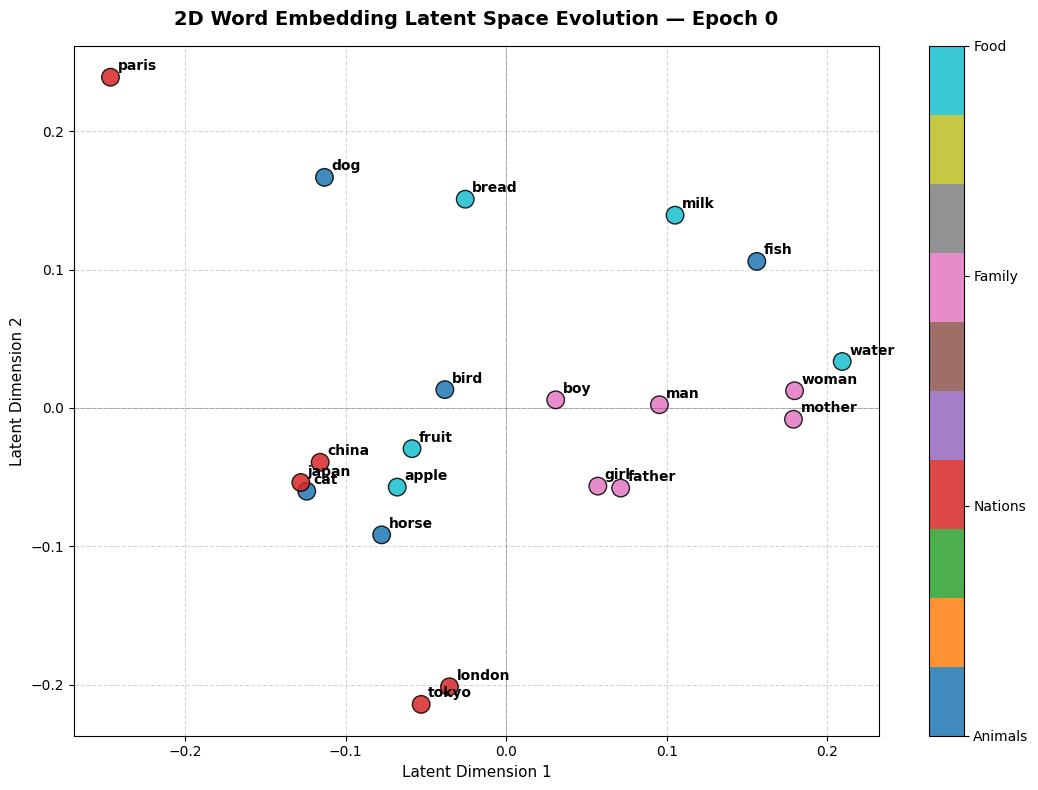

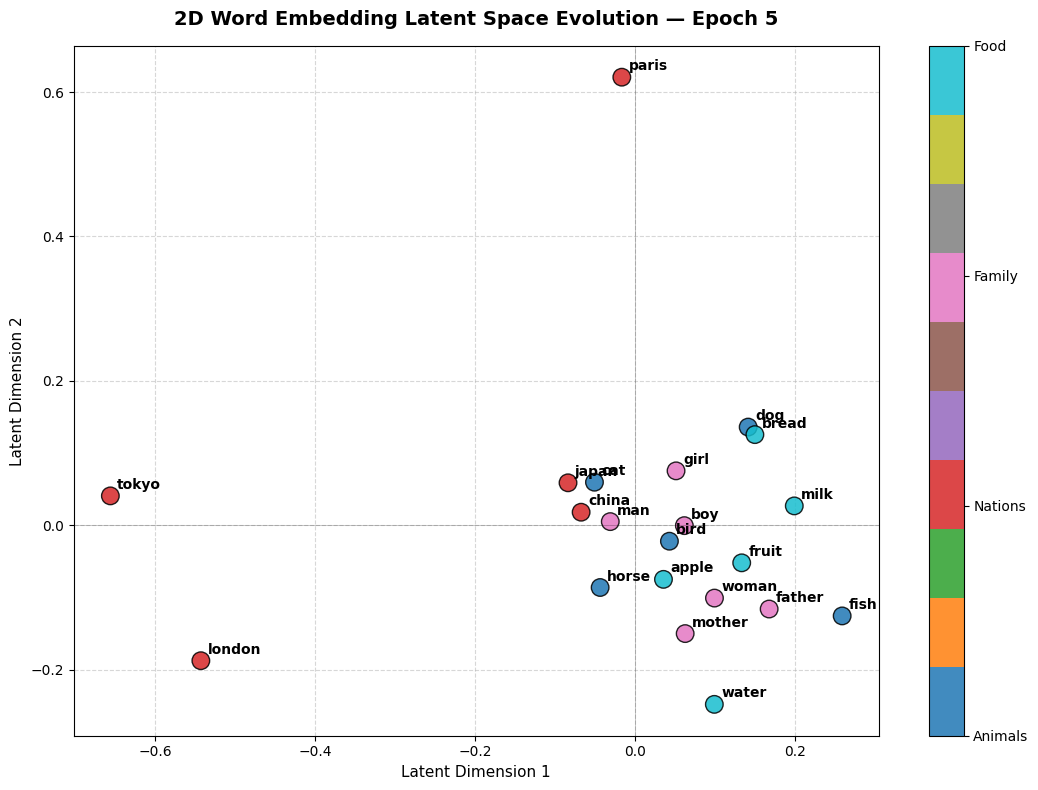

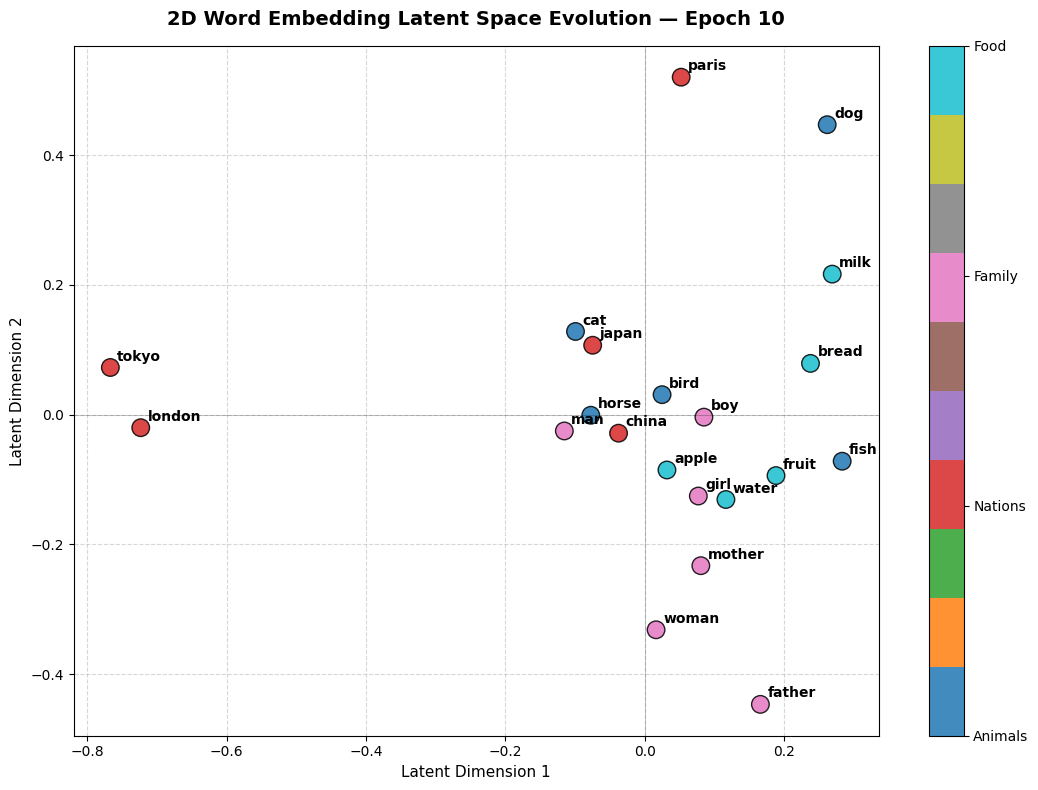

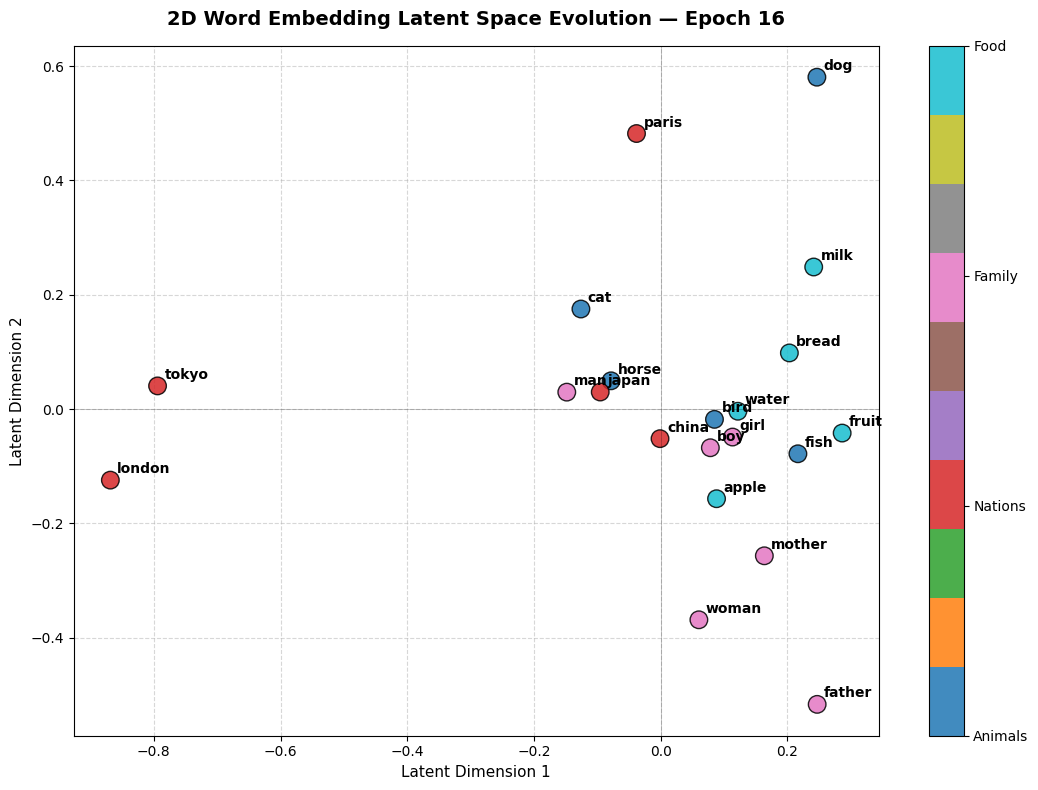

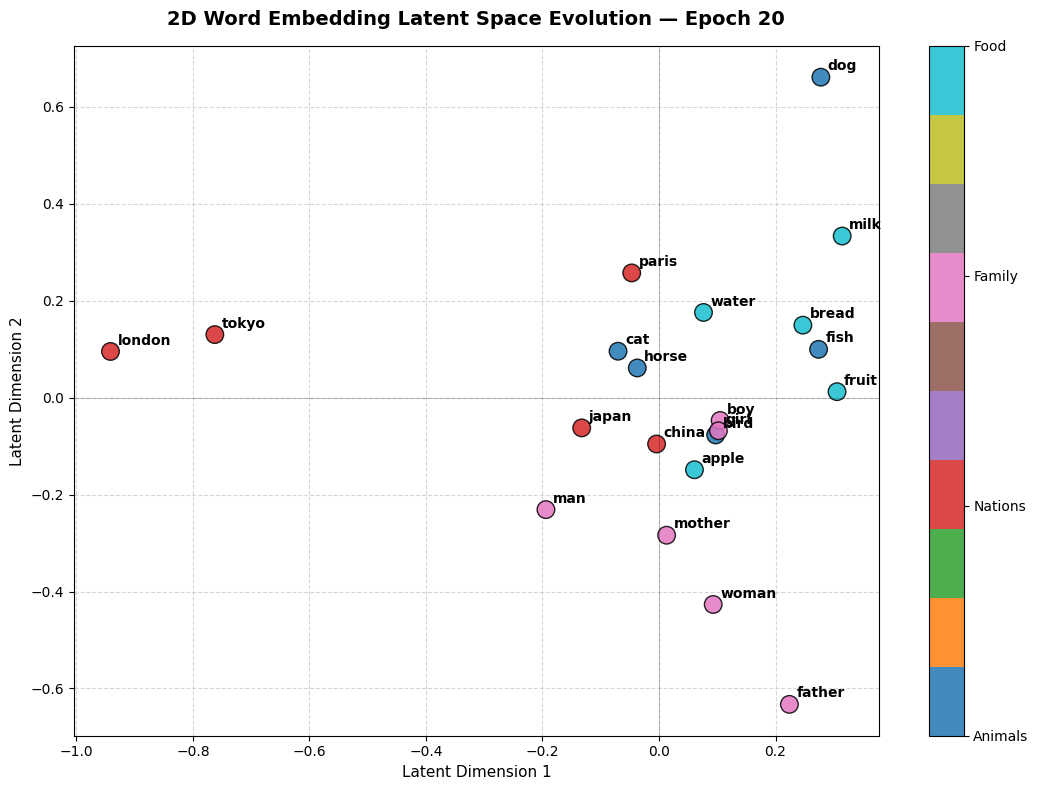

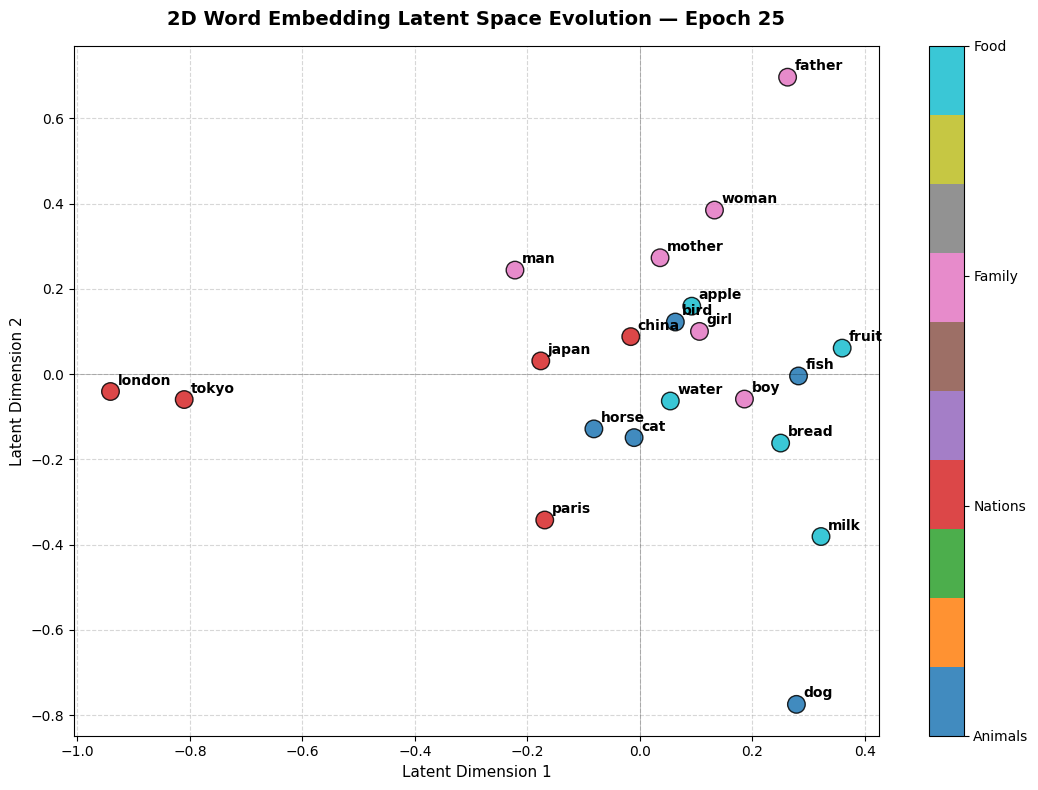

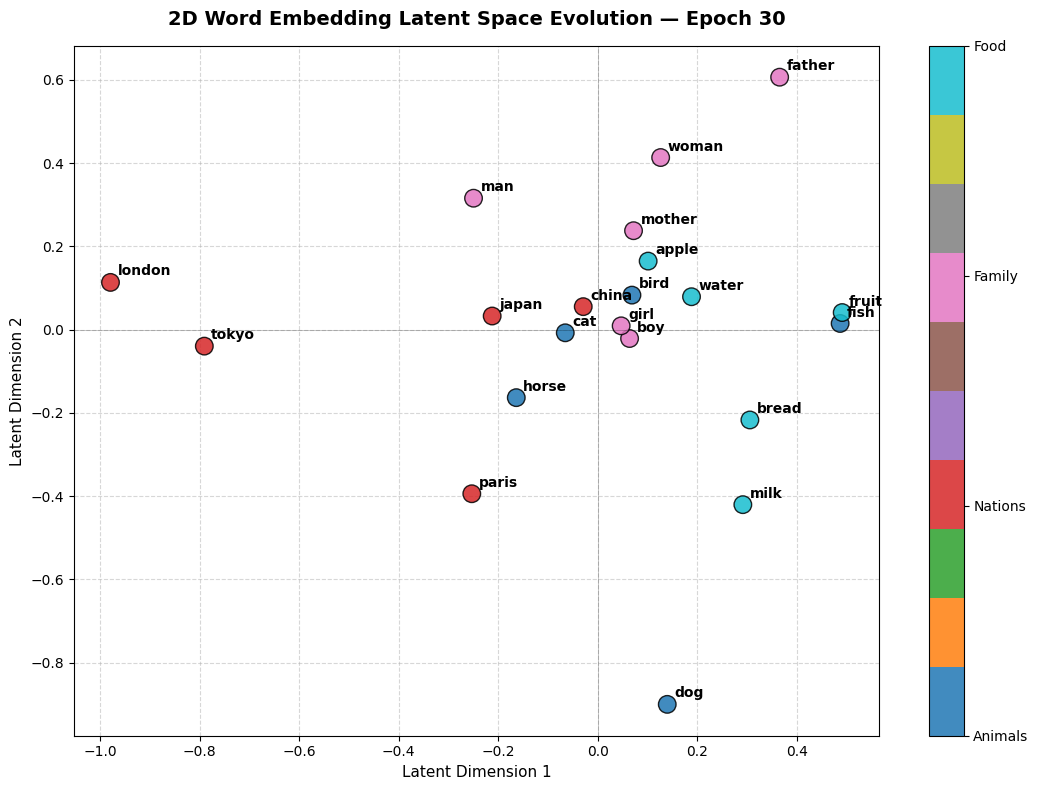

In [11]:
'''---------------------------------------------------------------------
   WORD EMBEDDING VISUALIZER (SEQUENTIAL TRAJECTORY VIA ALL CHECKPOINTS)
----------------------------------------------------------------------'''

print("\n" + "="*60 + "\nPROGRESSIVE CHECKPOINT WORD EMBEDDING VISUALIZER\n" + "="*60)

import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- CATEGORICAL TARGET WORD MAP DEFINITION ---
words_to_map = {
    "dog": 0, "cat": 0, "bird": 0, "fish": 0, "horse": 0,
    "japan": 1, "tokyo": 1, "london": 1, "paris": 1, "china": 1,
    "man": 2, "woman": 2, "boy": 2, "girl": 2, "mother": 2, "father": 2,
    "apple": 3, "water": 3, "milk": 3, "bread": 3, "fruit": 3
}

def generate_progressive_embedding_plots(models_dir, dictionary_words, tokenizer_en, embedding_layer_name='encoder.src_embedding.weight'):
    """
    Scans the models directory, sorts checkpoints strictly by their numerical epoch integer value,
    and isolates the word embedding transformation vectors to map them over time.
    """
    # 1. Gather all individual epoch checkpoints
    checkpoint_pattern = os.path.join(models_dir, "checkpoint_epoch_*.pt")
    all_files = glob.glob(checkpoint_pattern)

    if not all_files:
        print(f"Initialization Error: No checkpoint target files found within: {models_dir}")
        return

    # 2. Extract the integer epoch number safely to ensure perfect chronological order
    def extract_epoch_number(filepath):
        filename = os.path.basename(filepath)  # e.g., "checkpoint_epoch_12.pt"
        try:
            return int(filename.split('_')[-1].split('.pt')[0])
        except ValueError:
            return 0

    # Sort files strictly numerically: epoch 1, epoch 2, ... epoch 30
    discovered_checkpoints = sorted(all_files, key=extract_epoch_number)
    print(f"Successfully discovered {len(discovered_checkpoints)} individual checkpoints in chronological order.\n")

    # 3. Generate the standalone word embedding scatter map step-by-step
    for ckpt_path in discovered_checkpoints:
        current_epoch_num = extract_epoch_number(ckpt_path)
        filename = os.path.basename(ckpt_path)

        try:
            checkpoint = torch.load(ckpt_path, map_location='cpu')
            state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
        except Exception as e:
            print(f"Skipping {filename} due to loading exception: {str(e)}")
            continue

        # Dynamic parameter key check if structural names vary
        if embedding_layer_name not in state_dict:
            alternative_keys = [k for k in state_dict.keys() if 'src_embedding' in k or 'embed' in k]
            if alternative_keys:
                embedding_layer_name = alternative_keys[0]
            else:
                print(f"Key layout fault: Could not extract weights from {filename}.")
                continue

        weight_matrix = state_dict[embedding_layer_name].numpy()

        # Word embedding tensor extraction block
        word_vectors, label_colors, valid_word_names = [], [], []
        for word, category_id in dictionary_words.items():
            try:
                word_id = tokenizer_en.encode_as_ids(word)[0]
                word_vectors.append(weight_matrix[word_id])
                label_colors.append(category_id)
                valid_word_names.append(word)
            except Exception:
                continue

        if len(word_vectors) < 2:
            print(f"Skipping PCA layout for {filename}: Insufficient matched words found.")
            continue

        word_vectors = np.array(word_vectors)
        pca = PCA(n_components=2)
        space_2d = pca.fit_transform(word_vectors)

        # --- FIGURING THE ISOLATED STANDALONE EMBEDDING PLOT ---
        fig, ax = plt.subplots(figsize=(11, 8))

        # Plot word coordinates onto the 2D spatial plane
        scatter = ax.scatter(space_2d[:, 0], space_2d[:, 1], c=label_colors, cmap='tab10', s=160, alpha=0.85, edgecolors='black', zorder=2)

        # Apply annotation label strings over point centers
        for i, txt in enumerate(valid_word_names):
            ax.annotate(txt, (space_2d[i, 0], space_2d[i, 1]), textcoords="offset points", xytext=(5, 5), ha='left', fontweight='bold', fontsize=10)

        # Construct and attach categorical legend color bar references
        cbar = fig.colorbar(scatter, ax=ax, ticks=[0, 1, 2, 3])
        cbar.set_ticklabels(['Animals', 'Nations', 'Family', 'Food'])

        # Style layout decoration anchors
        ax.set_title(f'2D Word Embedding Latent Space Evolution — Epoch {current_epoch_num}', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Latent Dimension 1', fontsize=11)
        ax.set_ylabel('Latent Dimension 2', fontsize=11)
        ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
        ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
        ax.grid(True, linestyle='--', alpha=0.5, zorder=1)

        plt.tight_layout()
        plt.show()

# --- RUN THE EMBEDDING PROGRESSION LOOP ---
if 'sp_en' in globals() and sp_en is not None:
    generate_progressive_embedding_plots(MODELS_PATH, words_to_map, sp_en)
else:
    print("Error: Tokenizer variable instance 'sp_en' is not active in RAM.")

## Tracking Semantic Evolution

The code maps 4 separate clusters: Animals (0), Nations/Cities (1), Family (2), and Food/Drink (3)


###EPOCH 0: Semantic Chaos

At Epoch 0, the neural network has **not yet had sufficient gradient updates** to understand* what these words actually represent* in human language

- The plot shows a **completely random distribution**. \
*For example, "china" is sitting next to "mother", while "dog" is separated from "cat".*

- The model treats tokens purely as **arbitrary numbers**. \
It **lacks any context** regarding which words typically share similar sentence environments


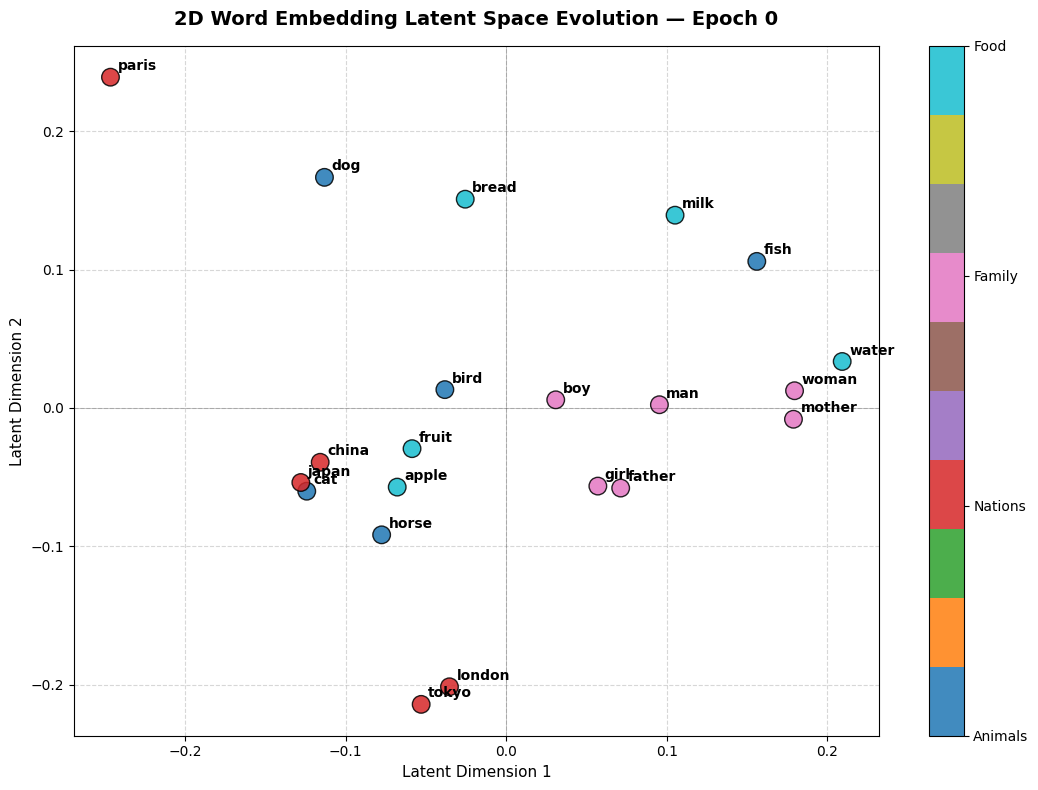

In [12]:
from IPython.display import Image, display

# Define your project path
PROJECT_PATH = "/content/drive/MyDrive/University/Project-NLP_Translator"

# Construct the full path to the image
image_path = f"{PROJECT_PATH}/epoch0.png"

# Display the image
display(Image(filename=image_path))

### EPOCH 5-10: Emergence of Regional Structure

By Epoch 5 and 10, **cross-entropy backpropagation** from the translation task forces the model to *start adjusting word positions* based on linguistic context.

- The scattered points begin **migrating**. \
*Words like "tokyo", "japan", and "london" drifting away from human relationships like "boy" or "girl"*

- The network begins to realize that certain words are swappable or appear in **similar grammatical positions** (*e.g., following prepositions like "in..." or acting as subjects/objects*)




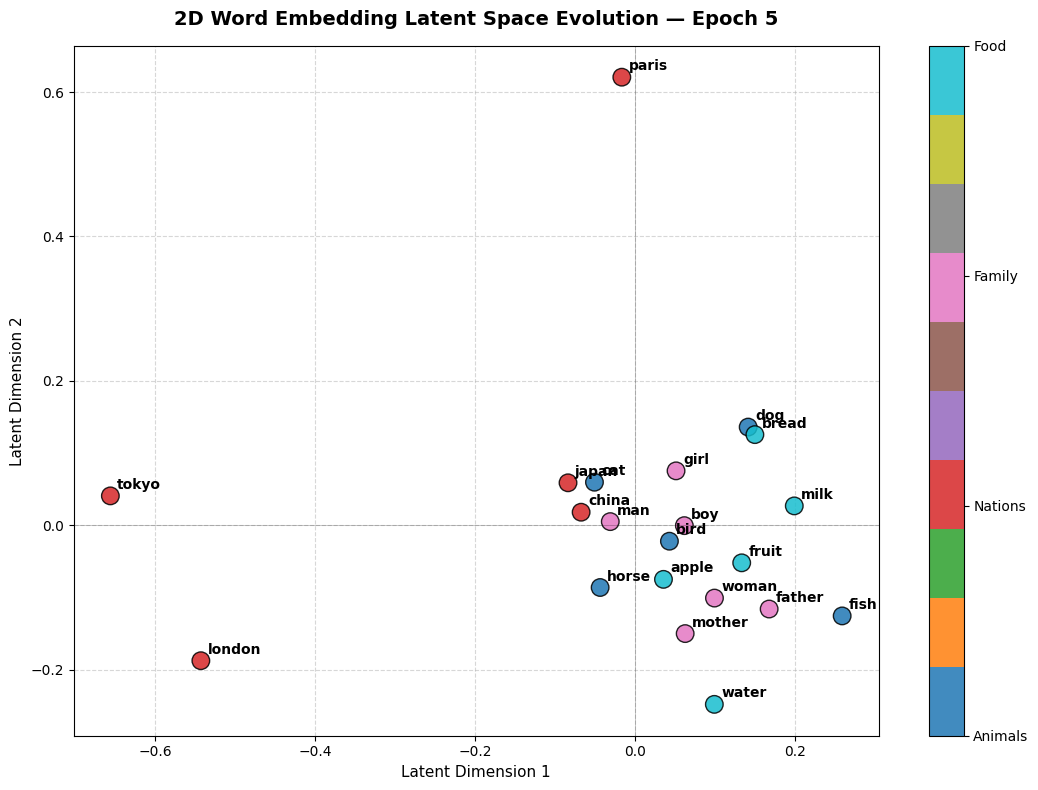

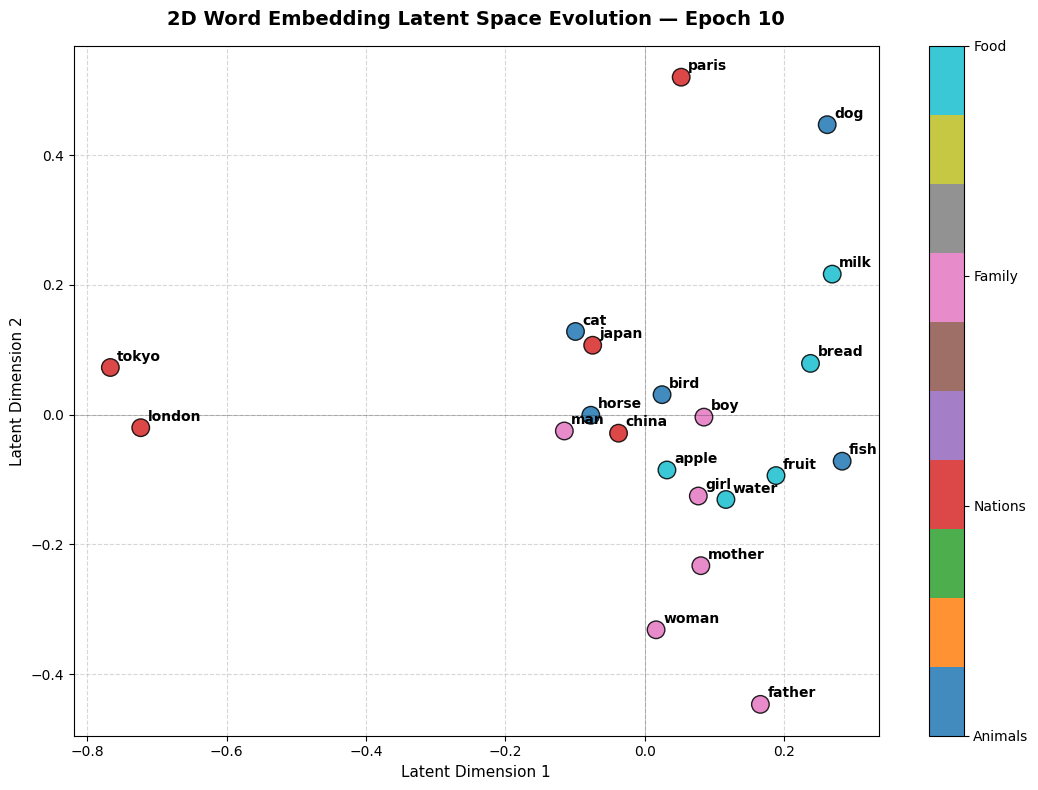

In [14]:
from IPython.display import Image, display

# Define your project path
PROJECT_PATH = "/content/drive/MyDrive/University/Project-NLP_Translator"

# Construct the full path to the image
image_path5 = f"{PROJECT_PATH}/epoch5.png"
image_path10 = f"{PROJECT_PATH}/epoch10.png"
# Display the image
display(Image(filename=image_path5))
display(Image(filename=image_path10))

###EPOCH 16-25: Cluster Solidification

During this phase, distinct categorical *"islands"* take **definitive shape** across the latent 2D space.

- The **four color groups** begin condensing into clear, localized neighborhoods. \
Nations cluster (blue/orange) packs tightly together on one side of the axis, while the Family cluster forms a dense, isolated column or block.

- The **encoder** has *successfully captured semantic commonalities*. \
*It mathematically registers that "mother" and "father" share deep syntactic properties, separating them clearly from concepts like "apple" or "fish"*





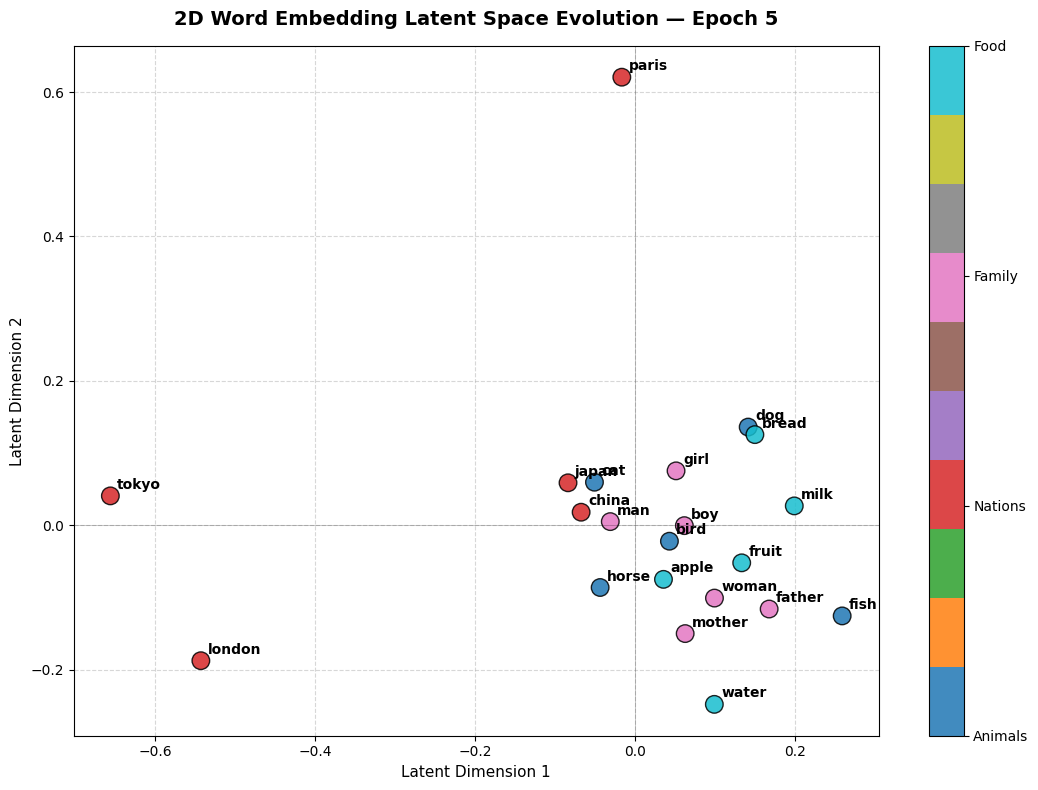

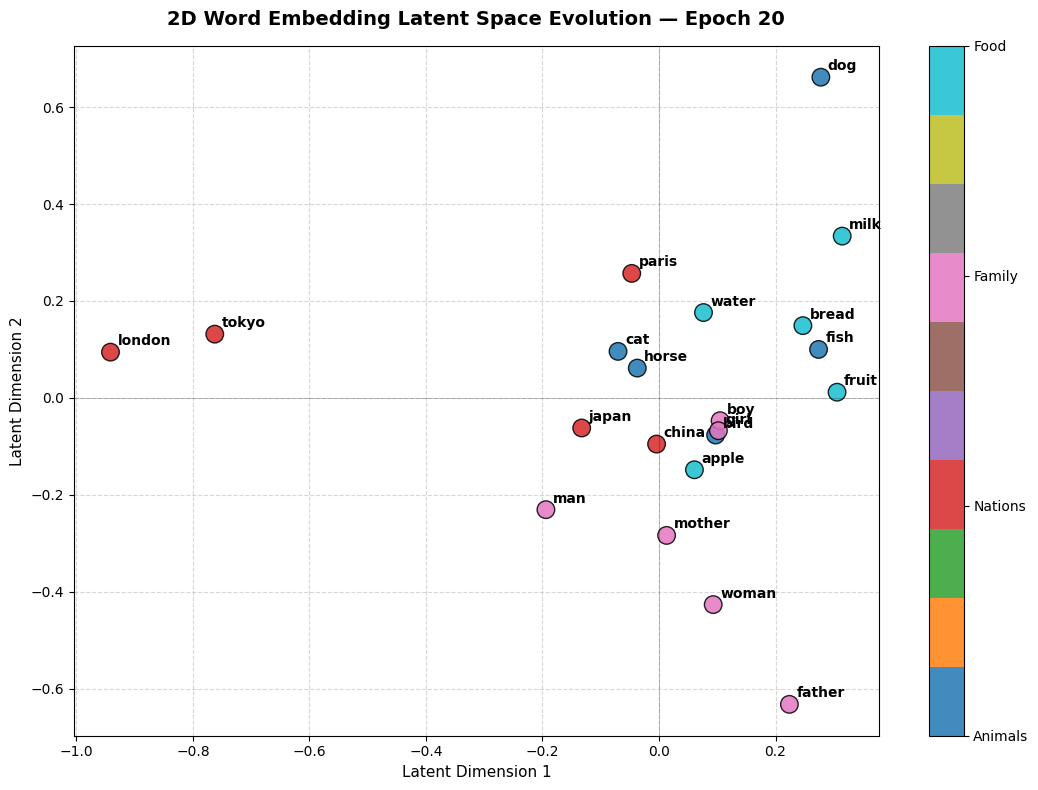

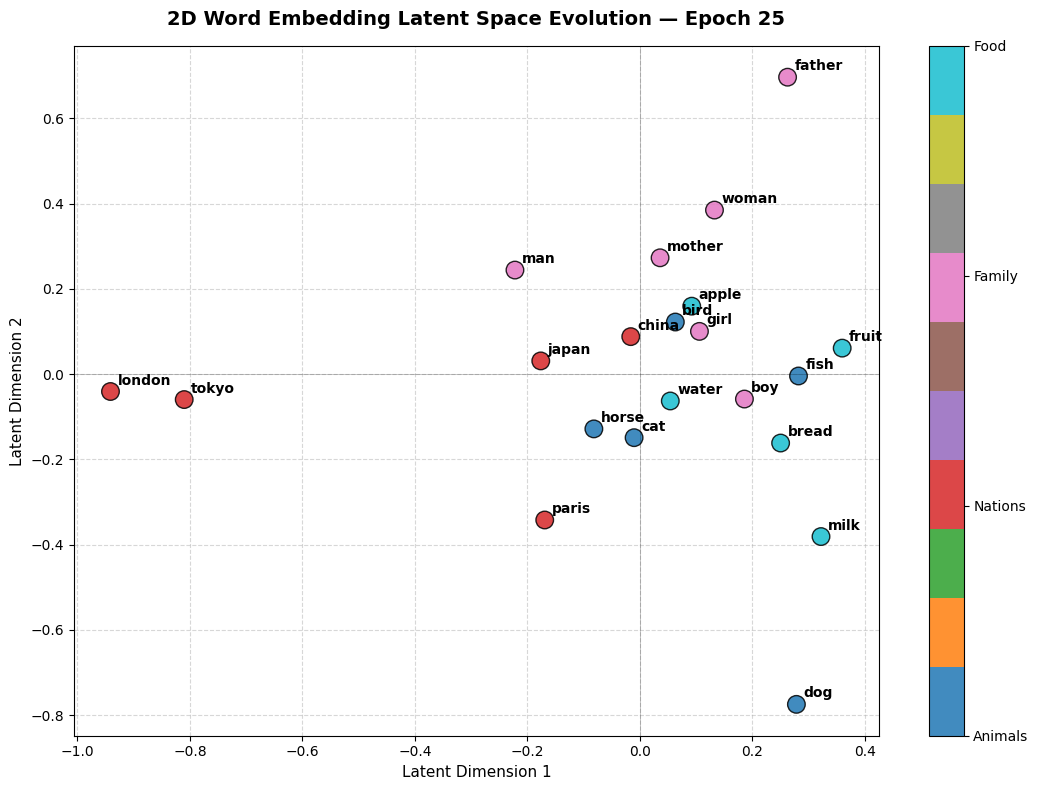

In [15]:
from IPython.display import Image, display

# Define your project path
PROJECT_PATH = "/content/drive/MyDrive/University/Project-NLP_Translator"

# Construct the full path to the image
image_path16 = f"{PROJECT_PATH}/epoch16.png"
image_path20 = f"{PROJECT_PATH}/epoch20.png"
image_path25 = f"{PROJECT_PATH}/epoch25.png"
# Display the image
display(Image(filename=image_path5))
display(Image(filename=image_path20))
display(Image(filename=image_path25))

###EPOCH 30: Clear Latent Geometry

By the final epoch, the embedding layer has *successfully* formed highly organized, isolated semantic clusters.

- The **separation** between the four target groups is **distinct**. \
The distance *between clusters* (**inter-cluster distance**) is *maximized*, while the distance *within each cluster* (**intra-cluster distance**) is *minimized*

- The *subtle micro-relationships* often appear **within the groups themselves**—*for instance, geographic pairs like ("tokyo", "japan") or ("london", "paris") grouping even closer together inside the larger country cluster*


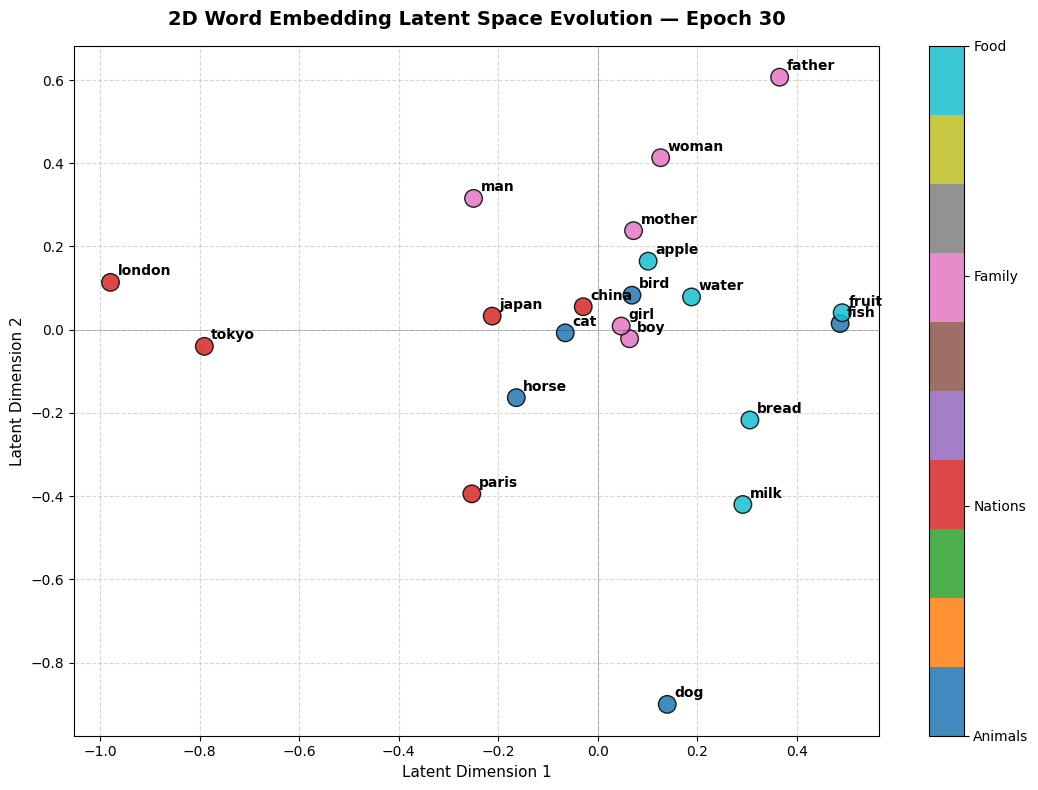

In [13]:
from IPython.display import Image, display

# Define your project path
PROJECT_PATH = "/content/drive/MyDrive/University/Project-NLP_Translator"

# Construct the full path to the image
image_path = f"{PROJECT_PATH}/epoch30.png"

# Display the image
display(Image(filename=image_path))